## Optimal Growth Temperature (OGT): phenotype prediction, feature selection, and data visualization

This notebook provides a pipeline for predicting the optimal growth temperature (OGT) and identifying genome footprints.

We train and test XGBoost regression on COG count tables, that are split into the test and train ones at a specified taxonomy level (i.e. all samples from a taxonomy group go to either train or test). The notebook can be run for one taxonomy level split.

To identify genome footprints and the most important features (COGs) contributing to the phenotype prediction, we use three different feature selection ranking methods:

- calculating the mutual information between the feature and the target label vector,
- using the feature weights returned by the random forest model,
- calculating SHAP values using the pre-trained XGBoost model.

The predictions of those three methods are compared between each other at the end of the notebook.

#### 1. Read the train and test datasets

First, we read the input files generated by *taxa_level_split.py*. The script generates 6 output files for the chosen [tax_level] of the train/test split, that are used as main inputs in this notebook. The files are the following:

- train_data_[tax_level]_tax_level : training count table,
- train_annot_[tax_level]_tax_level : training annotations,
- train_taxa_names_[tax_level]_tax_level : [tax_level] name of each training sample,

\+ 3 similar test tables. Those files should be stored in the corresponding directory for the phenotype.

In order to run the phenotype prediction pipeline in this notebook, the data directory with the input files, and [tax_level] of the train/test split should be specified below.

## Read the input data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

from utils.utils import read_ogt_data

# SPECIFY THE DESIRED TAXONOMY SPLIT LEVEL HERE!
TAX_LEVEL = "phylum" # <--------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_gc" # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <----------- number of splits to read and process is here!!

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.a

In [2]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_test, y_test, X_column_names, taxa_group_names_test = read_ogt_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_train, y_train, X_column_names, taxa_group_names_train = read_ogt_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)

    X_test = (X_test > 0).int()
    X_train = (X_train > 0).int()

    if sum(y_train)/len(y_train) < 0.01 or  sum(y_test)/len(y_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue
    if TAX_LEVEL == "random" or TAX_LEVEL == "domain":
        taxa_group_names_train = None
        taxa_group_names_test = None
    
    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_train
    curr_split_dict["y_train"] = y_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["X_test"] = X_test
    curr_split_dict["y_test"] = y_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["feature_names"] = X_column_names

    all_splits_dict[split_id] = curr_split_dict

In [3]:
X_train.shape

torch.Size([3581, 4789])

In [4]:
y_test.shape

torch.Size([153, 1])

In [65]:
y_train.shape

torch.Size([2985, 1])

In [66]:
all_splits_dict.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [54]:
mean_train = np.mean(y_train.cpu().squeeze().numpy())
mean_test = np.mean(y_test.cpu().squeeze().numpy())

print(f"Average GC of the train set = {mean_train}")
print(f"Average GC of the train set = {mean_test}")

Average GC of the train set = 52.082759857177734
Average GC of the train set = 52.45646667480469


2568
1166
4789


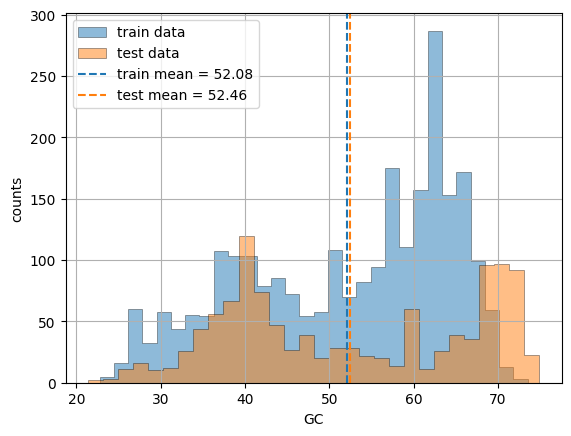

In [55]:
hist = plt.hist(y_train.cpu(), bins = 30, density = False, label = "train data", alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:blue')
hist = plt.hist(y_test.cpu(), bins = 30, density = False, label = "test data", alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:orange')
mean_value = y_train.cpu().mean().item()
plt.axvline(mean_value, color='tab:blue', linestyle='--', linewidth=1.5, label=f'train mean = {mean_value:.2f}')
mean_value = y_test.cpu().mean().item()
plt.axvline(mean_value, color='tab:orange', linestyle='--', linewidth=1.5, label=f'test mean = {mean_value:.2f}')


plt.xlabel("GC")
plt.ylabel("counts")
plt.grid(True)
plt.legend();
print(len(y_train.cpu()))
print(len(y_test.cpu()))
print(len(X_column_names))

In [9]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="Your system has an old version of glibc.*"
)

# Suppress KBinsDiscretizer quantile method deprecation warning
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="The current default behavior, quantile_method='linear'.*"
)

# Suppress constant feature replacement warning
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="Feature .* is constant and will be replaced with 0"
)

In [8]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from feature_selection.feature_selection_utils import iamb
import warnings
from sklearn.preprocessing import KBinsDiscretizer
import json

filename = f"{OUTPUT_DIRECTORY}/markov_boundaries.json"
all_markov_bound_dict = defaultdict(int)


if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_markov_bound_dict = json.load(f)
else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
    
        X_np = X_val_train.cpu().numpy()  
        y_np = y_label_train.squeeze().cpu().numpy()  #y_label_train.cpu().numpy()  
    
        # Suppress only the specific warning from KBinsDiscretizer about small bin widths
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Feature .* is constant and will be replaced with 0.")
            warnings.filterwarnings("ignore", message="Your system has an old version of glibc.*")
            warnings.filterwarnings("ignore", message="Bins whose width are too small")

            X_np = (X_np > 0).astype(int)
            
            selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
            X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])
        
            # e.g., split y into 3 bins (low, medium, high)
            disc = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
            y_disc = disc.fit_transform(y_np.reshape(-1, 1)).ravel()
            #print(y_np.reshape(-1, 1))
           # print(y_disc)

            mutual_info = mutual_info_classif(X_np, y_disc, random_state=42)
            sorted_indices = np.argsort(mutual_info)[::-1] 
            N = 500
            top_N_indices = sorted_indices[:N]
           
            X_filtered = X_filtered.iloc[:, top_N_indices]
            print(X_filtered.shape)
            
            markov_boundary = iamb(X_filtered, y_disc, contin = False, alpha=0.01, verbose=False)
        print("Markov Boundary:", markov_boundary)
    
        all_markov_bound_dict[split_id] = markov_boundary


    with open(filename, "w") as f:
        json.dump(dict(all_markov_bound_dict), f, indent=2)

Reading the existing file...


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


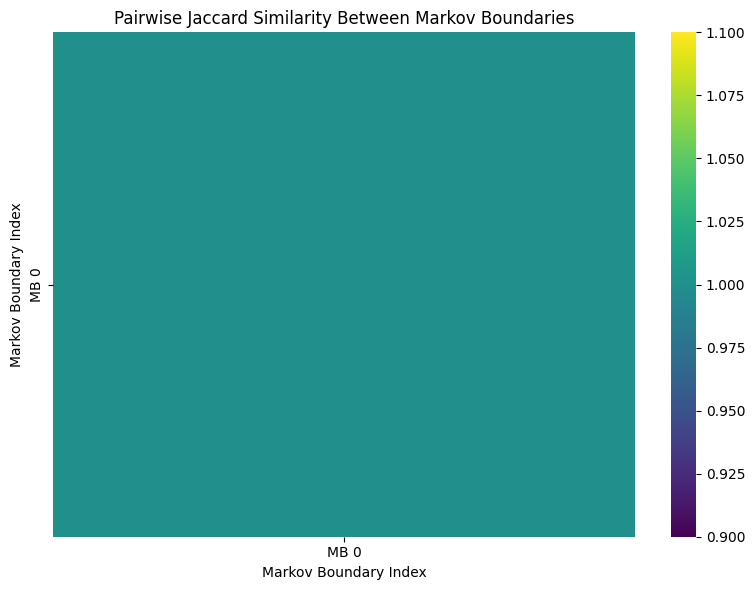

In [165]:
import seaborn as sns
from itertools import combinations
import pandas as pd

markov_boundaries = []

for split_id in all_markov_bound_dict.keys():
    markov_boundaries.append(set(all_markov_bound_dict[split_id])) 
# Number of sets
n = len(markov_boundaries)

# Compute pairwise Jaccard similarity matrix
jaccard_matrix = np.zeros((n, n))
jacc_idices = []
for i in range(n):
    for j in range(n):
        a, b = markov_boundaries[i], markov_boundaries[j]
        union = a | b
        intersection = a & b
        jaccard_index = len(intersection) / len(union) if union else 0
        jaccard_matrix[i, j] = jaccard_index
        if i>j:
            jacc_idices.append(jaccard_index)
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=False, fmt=".2f", cmap="viridis", cbar=True,
            xticklabels=[f"MB {i}" for i in range(n)],
            yticklabels=[f"MB {i}" for i in range(n)])
plt.title("Pairwise Jaccard Similarity Between Markov Boundaries")
plt.xlabel("Markov Boundary Index")
plt.ylabel("Markov Boundary Index")
plt.tight_layout()
plt.show()


In [166]:
num_splits = len(all_markov_bound_dict.keys())

all_cogs = sorted(set(cog for lst in all_markov_bound_dict.values() for cog in lst))
presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_markov_bound_dict])
for i, cogs in all_markov_bound_dict.items():
    presence_df.loc[cogs, f"Split_{i}"] = 1

# Add frequency column
presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# Sort by frequency
presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)



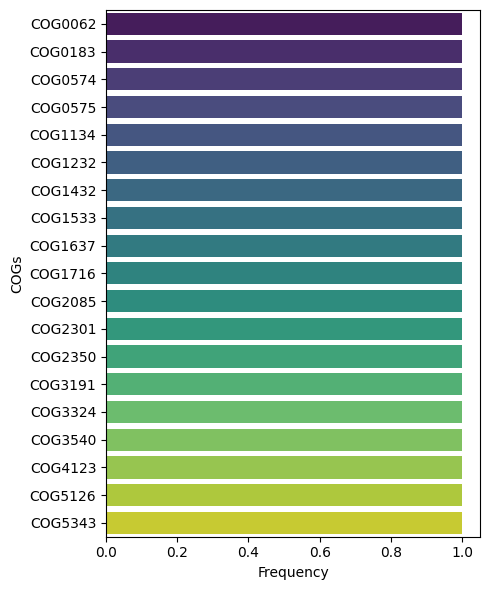

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5, 6))
sns.barplot(
    x="Frequency",
    y=presence_df_sorted.index,
    data=presence_df_sorted.reset_index(),
    hue="index",  # use index as hue to apply the palette
    palette="viridis",
    dodge=False,
    legend=False
)
plt.xlabel("Frequency")
plt.ylabel("COGs")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/markov_boundar_cogs.pdf", format="pdf")

In [168]:
dict_mb_stats = defaultdict(str)
dict_mb_stats["jaccard_aver"] = np.mean(jacc_idices)
dict_mb_stats["jaccard_std"] = np.std(jacc_idices)
print(f"Ave. Jaccard indec = {np.mean(jacc_idices)}; std = {np.std(jacc_idices)}")

Ave. Jaccard indec = nan; std = nan


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [169]:
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features


all_markov_bound_dict_with_res = {}#defaultdict(int)
mb_lengths = []

for split_id in all_markov_bound_dict.keys():
    mb_lengths.append(len(all_markov_bound_dict[split_id]))
    markov_bound = all_markov_bound_dict[split_id]
    indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
    split_dict = defaultdict(str)
    split_dict["MB"] = markov_bound[:]
    # split_dict["cv_accuracy_scores"] = cv_accuracy_scores.copy()
    # split_dict["test_accuracy_scores"] = test_accuracy_scores.copy()
    all_markov_bound_dict_with_res[split_id] = split_dict.copy()



print(f"Average MB length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")    

Average MB length = 19.0; std = 0.0


In [170]:
dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
dict_mb_stats["mb_length_std"] = np.std(mb_lengths)
df = pd.DataFrame([dict_mb_stats])

# Save to CSV
df.to_csv(f"{OUTPUT_DIRECTORY}/mb_summary.csv", index=False)
df

,jaccard_aver,jaccard_std,mb_length_aver,mb_length_std
0,NaN,NaN,19.0,0.0


In [171]:
import math

aver_mb_len = math.ceil(np.mean(mb_lengths))
aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

with open(f"{OUTPUT_DIRECTORY}/aver_mb.txt", "w") as f:
    f.write(f"{aver_m_names}\n")
        
aver_m_names

['COG0062',
 'COG0183',
 'COG0574',
 'COG0575',
 'COG1134',
 'COG1232',
 'COG1432',
 'COG1533',
 'COG1637',
 'COG1716',
 'COG2085',
 'COG2301',
 'COG2350',
 'COG3191',
 'COG3324',
 'COG3540',
 'COG4123',
 'COG5126',
 'COG5343']

In [172]:
def label_ogt_range(y,high_thresh=50):
    labels = []
    for val in y:
        if val < high_thresh:
            labels.append('low')
        else:
            labels.append('high')
    return np.array(labels)

In [90]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)


acuracy_across_mb = defaultdict(list)

for i in range(1, len(aver_m_names) + 1):
    print(f"Processing {i} i...")
    cv_accur_dict_splits = defaultdict(list)
    test_accur_dict_splits = defaultdict(list)
    test_accur_dict_splits_baseline = defaultdict(list)

    for split_id in all_splits_dict.keys():
      #  print(f"split = {split_id}")
        X_val_train = all_splits_dict[split_id]["X_train"]
        y_label_train = all_splits_dict[split_id]["y_train"]
        X_val_test = all_splits_dict[split_id]["X_test"]
        y_label_test = all_splits_dict[split_id]["y_test"]
        
        if TAX_LEVEL == "domain":
            taxa_group_names_train = None
        else:    
            taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]
            
        aver_m_names_local = aver_m_names[:i]
        indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
        
        range_labels = label_ogt_range(y_label_train)
        le = LabelEncoder()
        range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
        label_to_int = {'low': 0, 'high': 1}
        range_ids = np.vectorize(label_to_int.get)(range_labels)
    
        classes = np.unique(range_ids)
        weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
        class_weights = dict(zip(classes, weights))
        #class_weights[0]=1
       # class_weights[1]=10
        sample_weights = np.array([class_weights[c] for c in range_ids])
    
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
       # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
        for accur_measure in dict_res_two_class["cv_metrics"].keys():
            cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
            test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])
    
        temp_bound = 50
        y_label_test_bin  = (y_label_test.squeeze() > 50).long().cpu().numpy()
    
        #Calculate the baseline accuracies
        N_tot = len(y_label_test_bin)
        N_1 = sum(y_label_test_bin).item()
        N_0 = N_tot - N_1
        fp = tn = N_0/2
        tp = fn = N_1/2
    
        if tp+fn >0:
            pres = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*(pres*recall)/(pres+recall)
        
            test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
            test_accur_dict_splits_baseline["precision"].append(pres)
            test_accur_dict_splits_baseline["recall"].append(recall)
            test_accur_dict_splits_baseline["f1"].append(f1)
            
        mean_val = y_label_test.mean().cpu()
        mean_tensor = torch.full_like(y_label_test, mean_val)
        rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))
    
        test_accur_dict_splits_baseline["r2"].append(0)
        test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)
    
        
        y_true = dict_res_two_class["cv_true"]
        y_pred = dict_res_two_class["cv_predictions"]
        
        rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
        cv_accur_dict_splits["rmse"].append(rmse_cv)
        r2_cv = r2_score(y_true, y_pred)
        cv_accur_dict_splits["r2"].append(r2_cv)
    
        # Boolean masks
        mask_high = (y_true > 50).squeeze()
        mask_low = (y_true < 50).squeeze()
    
       # print(f"y_true[mask_high] = {y_true[mask_high]}")
       # print(f"y_pred[mask_high] = {y_pred[mask_high]}")
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
        cv_accur_dict_splits["rmse_high"].append(rmse_high)
        cv_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        cv_accur_dict_splits["rmse_low"].append(rmse_low)
        cv_accur_dict_splits["r2_low"].append(r2_low)
    
    
        y_true = y_label_test.cpu()
        y_pred = dict_res_two_class["test_predictions"]
        
        rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
        test_accur_dict_splits["rmse"].append(rmse_test)
        r2_test = r2_score(y_true, y_pred)
        test_accur_dict_splits["r2"].append(r2_test)
    
        # Boolean masks
        mask_high = (y_true > 50).squeeze()
        mask_low = (y_true < 50).squeeze()
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
        test_accur_dict_splits["rmse_high"].append(rmse_high)
        test_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        test_accur_dict_splits["rmse_low"].append(rmse_low)
        test_accur_dict_splits["r2_low"].append(r2_low)

    cv_accur_dict_mean = defaultdict(float)
    cv_accur_dict_std = defaultdict(float)
    test_accur_dict_mean = defaultdict(float)
    test_accur_dict_std = defaultdict(float)
    test_accur_dict_splits_baseline_mean = defaultdict(float)
    test_accur_dict_splits_baseline_std = defaultdict(float)
    for accur_measure in cv_accur_dict_splits.keys():
        cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
        cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
        test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
        test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
        test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
        test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

    metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
    acuracy_across_mb[i] = metrics    

NameError: name 'aver_m_names' is not defined

In [174]:
df = pd.DataFrame(acuracy_across_mb)
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])

df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_across_aver_mb.csv")

Text(0.5, 1.0, 'F1')

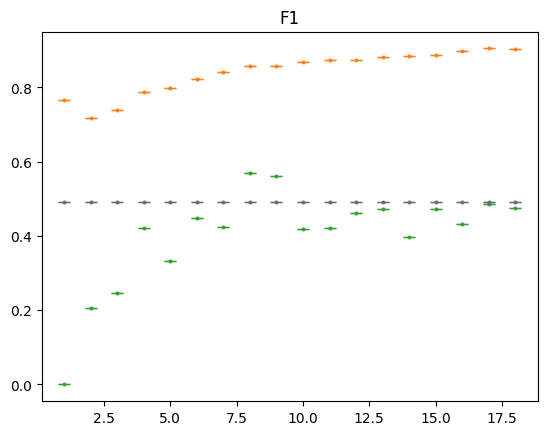

In [175]:
metric = 'f1'
for i in list(acuracy_across_mb.keys())[:-1]:
    plt.errorbar(
    i,
    acuracy_across_mb[i]['cv mean'][metric],
    yerr=acuracy_across_mb[i]['cv std'][metric],
    fmt='-o',
    color="tab:orange",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test mean'][metric],
    yerr=acuracy_across_mb[i]['test std'][metric],
    fmt='-o',
    color="tab:green",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test baseline mean'][metric],
    yerr=acuracy_across_mb[i]['test baseline std'][metric],
    fmt='-o',
    color="dimgray",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
plt.title("F1")

Text(0.5, 1.0, 'R^2')

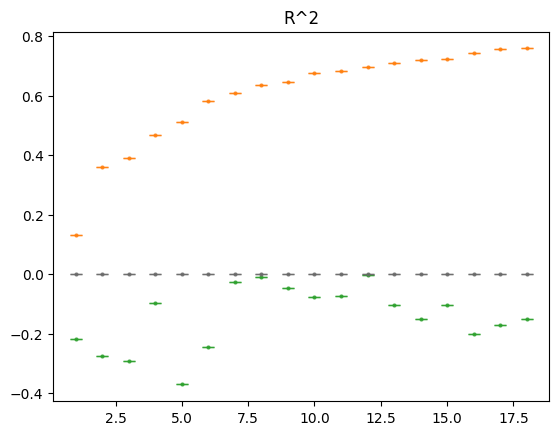

In [176]:
metric = 'r2'
for i in list(acuracy_across_mb.keys())[:-1]:
    plt.errorbar(
    i,
    acuracy_across_mb[i]['cv mean'][metric],
    yerr=acuracy_across_mb[i]['cv std'][metric],
    fmt='-o',
    color="tab:orange",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test mean'][metric],
    yerr=acuracy_across_mb[i]['test std'][metric],
    fmt='-o',
    color="tab:green",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test baseline mean'][metric],
    yerr=acuracy_across_mb[i]['test baseline std'][metric],
    fmt='-o',
    color="dimgray",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
plt.title("R^2")

In [14]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight

In [177]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight


cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if TAX_LEVEL == "domain":
        taxa_group_names_train = None
    else:    
        taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]
    indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = 50
    y_label_test_bin  = (y_label_test.squeeze() > 45).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    
    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()

    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)


    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > 45).squeeze()
    mask_low = (y_true < 45).squeeze()
    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std}

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_aver_mb.csv")

print(df)

Processing 0 split...
            cv mean  cv std  test mean  test std  test baseline mean  \
accuracy   0.894722     0.0   0.529412       0.0            0.500000   
precision  0.917961     0.0   0.517241       0.0            0.562092   
recall     0.900905     0.0   0.405405       0.0            0.500000   
f1         0.909353     0.0   0.454545       0.0            0.529231   
rmse       6.328717     0.0  11.721526       0.0           10.831813   
r2         0.760887     0.0  -0.171025       0.0            0.000000   
rmse_low   6.623803     0.0  12.610419       0.0                 NaN   
r2_low    -0.165863     0.0  -4.647293       0.0                 NaN   
rmse_high  6.109277     0.0  10.979257       0.0                 NaN   
r2_high   -0.049050     0.0  -2.076637       0.0                 NaN   

           test baseline std  
accuracy                 0.0  
precision                0.0  
recall                   0.0  
f1                       0.0  
rmse                     0.0  

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [179]:
cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if TAX_LEVEL == "domain":
        taxa_group_names_train = None
    else:    
        taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]

    mbs = all_markov_bound_dict_with_res[int(split_id)]['MB']
    indices = [i for i, val in enumerate(X_column_names) if val in mbs]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = 50
    y_label_test_bin  = (y_label_test.squeeze() > 45).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    
    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()

    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)


    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()
    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std}

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_individ_mb.csv")

print(df)

Processing 0 split...
            cv mean  cv std  test mean  test std  test baseline mean  \
accuracy   0.894722     0.0   0.529412       0.0            0.500000   
precision  0.917961     0.0   0.517241       0.0            0.562092   
recall     0.900905     0.0   0.405405       0.0            0.500000   
f1         0.909353     0.0   0.454545       0.0            0.529231   
rmse       6.328717     0.0  11.721526       0.0           10.831813   
r2         0.760887     0.0  -0.171025       0.0            0.000000   
rmse_low   6.623803     0.0  11.824593       0.0                 NaN   
r2_low    -0.165863     0.0  -2.841842       0.0                 NaN   
rmse_high  6.109277     0.0  11.610488       0.0                 NaN   
r2_high   -0.049050     0.0  -3.324049       0.0                 NaN   

           test baseline std  
accuracy                 0.0  
precision                0.0  
recall                   0.0  
f1                       0.0  
rmse                     0.0  

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [180]:
import random

random_mbs = defaultdict(list)
num_rand_samples = 10
N = len(aver_m_names)
for split_id in all_splits_dict.keys():
    for _ in range(num_rand_samples):
        random_feature_subset = random.sample(list(X_column_names), N)
        random_mbs[split_id].append(random_feature_subset)

In [181]:
cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if TAX_LEVEL == "domain":
        taxa_group_names_train = None
    else:    
        taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]

    for l in range(num_rand_samples):
        aver_m_names_local = random_mbs[split_id][l]# random_feature_subset[:i]
        indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
    
  #  mbs = all_markov_bound_dict_with_res[str(split_id)]['MB']
   # indices = [i for i, val in enumerate(X_column_names) if val in mbs]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

        temp_bound = 50
        y_label_test_bin  = (y_label_test.squeeze() > 45).long().cpu().numpy()
    
        #Calculate the baseline accuracies
        N_tot = len(y_label_test_bin)
        N_1 = sum(y_label_test_bin).item()
        N_0 = N_tot - N_1
        fp = tn = N_0/2
        tp = fn = N_1/2
    
        if tp+fn >0:
            pres = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*(pres*recall)/(pres+recall)
        
            test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
            test_accur_dict_splits_baseline["precision"].append(pres)
            test_accur_dict_splits_baseline["recall"].append(recall)
            test_accur_dict_splits_baseline["f1"].append(f1)
            
        mean_val = y_label_test.mean().cpu()
        mean_tensor = torch.full_like(y_label_test, mean_val)
        rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))
    
        test_accur_dict_splits_baseline["r2"].append(0)
        test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)
    
        
        y_true = dict_res_two_class["cv_true"]
        y_pred = dict_res_two_class["cv_predictions"]
        
        rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
        cv_accur_dict_splits["rmse"].append(rmse_cv)
        r2_cv = r2_score(y_true, y_pred)
        cv_accur_dict_splits["r2"].append(r2_cv)
    
        # Boolean masks
        mask_high = (y_true > 50).squeeze()
        mask_low = (y_true < 50).squeeze()
    
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
        cv_accur_dict_splits["rmse_high"].append(rmse_high)
        cv_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        cv_accur_dict_splits["rmse_low"].append(rmse_low)
        cv_accur_dict_splits["r2_low"].append(r2_low)
    
    
        y_true = y_label_test.cpu()
        y_pred = dict_res_two_class["test_predictions"]
        
        rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
        test_accur_dict_splits["rmse"].append(rmse_test)
        r2_test = r2_score(y_true, y_pred)
        test_accur_dict_splits["r2"].append(r2_test)
    
        # Boolean masks
        mask_high = (y_true > 50).squeeze()
        mask_low = (y_true < 50).squeeze()
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
        test_accur_dict_splits["rmse_high"].append(rmse_high)
        test_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        test_accur_dict_splits["rmse_low"].append(rmse_low)
        test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std}

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_random_mb.csv")

print(df)

Processing 0 split...
             cv mean  cv std  test mean  test std  test baseline mean  \
accuracy    0.768221     0.0   0.607843       0.0            0.500000   
precision   0.875666     0.0   0.675000       0.0            0.562092   
recall      0.704621     0.0   0.364865       0.0            0.500000   
f1          0.780887     0.0   0.473684       0.0            0.529231   
rmse        9.851189     0.0  10.511451       0.0           10.831813   
r2          0.420640     0.0   0.058277       0.0            0.000000   
rmse_low    9.461471     0.0   9.021442       0.0                 NaN   
r2_low     -1.378757     0.0  -1.236243       0.0                 NaN   
rmse_high  10.118737     0.0  11.897953       0.0                 NaN   
r2_high    -1.877858     0.0  -3.540818       0.0                 NaN   

           test baseline std  
accuracy                 0.0  
precision                0.0  
recall                   0.0  
f1                       0.0  
rmse               

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

## SHAP

In [182]:
from feature_selection.feature_selection_utils import shap_features
import warnings
from sklearn.preprocessing import KBinsDiscretizer
import json

filename = f"{OUTPUT_DIRECTORY}/shap_list.json"
all_shap_lists_dict = defaultdict(int)
device = 'cpu'


if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_shap_lists_dict = json.load(f)

else:
    for split_id in range(NUM_SPLITS_TO_READ):
      #  split_id = str(split_id)
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
        X_column_names =  all_splits_dict[split_id]["feature_names"]

        X_np = X_val_train.cpu().numpy()  
        X_np = X_np[:, :-20]
        X_np = (X_np > 0).astype(int)

        sorted_cog_idx_by_shap, sorted_shap, sorted_names, shap_vals  = shap_features(X_np, y_label_train.cpu(), X_column_names, device, contin_flag = True) 
    
        N = len(all_markov_bound_dict[split_id])
        print("SHAP list:", sorted_names[:N])
    
        all_shap_lists_dict[split_id] = sorted_names[:N]


    with open(filename, "w") as f:
        json.dump(dict(all_shap_lists_dict), f, indent=2)

Processing split 0
SHAP list: ['COG1643', 'COG1391', 'COG2331', 'COG1201', 'COG3066', 'COG0380', 'COG1274', 'COG2996', 'COG1432', 'COG1054', 'COG1193', 'COG2151', 'COG1804', 'COG1194', 'COG0745', 'COG3824', 'COG2171', 'COG3280', 'COG1327']


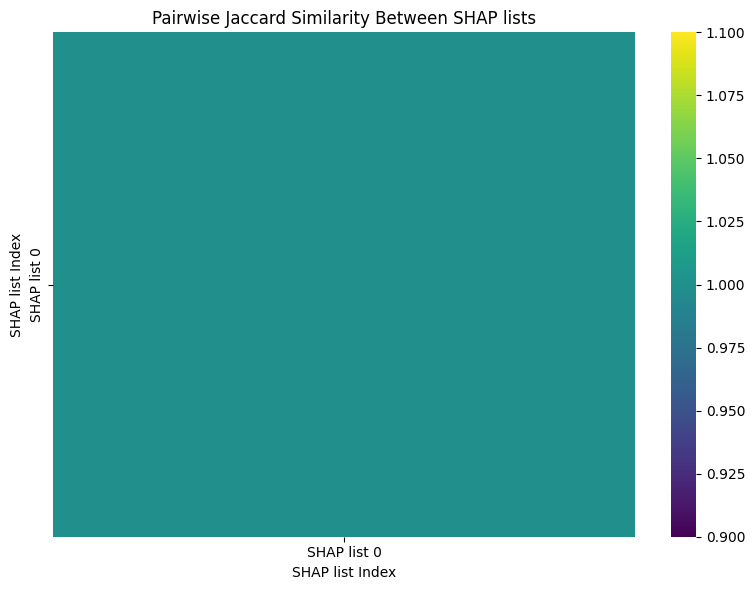

In [183]:
import seaborn as sns
from itertools import combinations
import pandas as pd

shap_lists = []

for split_id in all_shap_lists_dict.keys():
    shap_lists.append(set(all_shap_lists_dict[split_id])) 
# Number of sets
n = len(shap_lists)

# Compute pairwise Jaccard similarity matrix
jaccard_matrix = np.zeros((n, n))
jacc_idices = []
for i in range(n):
    for j in range(n):
        a, b = shap_lists[i], shap_lists[j]
        union = a | b
        intersection = a & b
        jaccard_index = len(intersection) / len(union) if union else 0
        jaccard_matrix[i, j] = jaccard_index
        if i>j:
            jacc_idices.append(jaccard_index)
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=False, fmt=".2f", cmap="viridis", cbar=True,
            xticklabels=[f"SHAP list {i}" for i in range(n)],
            yticklabels=[f"SHAP list {i}" for i in range(n)])
plt.title("Pairwise Jaccard Similarity Between SHAP lists")
plt.xlabel("SHAP list Index")
plt.ylabel("SHAP list Index")
plt.tight_layout()
plt.show()


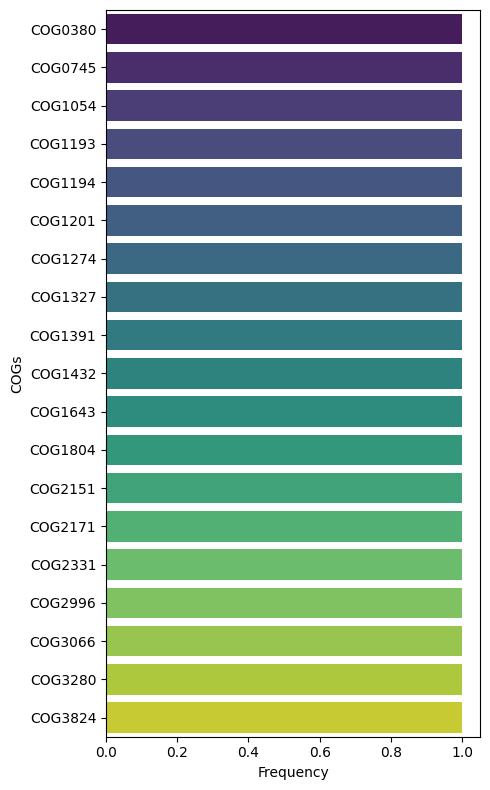

In [184]:
num_splits = len(all_shap_lists_dict.keys())

all_cogs = sorted(set(cog for lst in all_shap_lists_dict.values() for cog in lst))
presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_shap_lists_dict])
for i, cogs in all_shap_lists_dict.items():
    presence_df.loc[cogs, f"Split_{i}"] = 1

# Add frequency column
presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# Sort by frequency
presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5, 8))
sns.barplot(
    x="Frequency",
    y=presence_df_sorted.index,
    data=presence_df_sorted.reset_index(),
    hue="index",  # use index as hue to apply the palette
    palette="viridis",
    dodge=False,
    legend=False
)
plt.xlabel("Frequency")
plt.ylabel("COGs")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/shap_lists_cogs.pdf", format="pdf")

In [185]:
dict_mb_stats = defaultdict(str)
dict_mb_stats["jaccard_aver"] = np.mean(jacc_idices)
dict_mb_stats["jaccard_std"] = np.std(jacc_idices)
print(f"Ave. Jaccard indec = {np.mean(jacc_idices)}; std = {np.std(jacc_idices)}")

Ave. Jaccard indec = nan; std = nan


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [186]:
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features


all_shap_lists_dict_with_res = {}#defaultdict(int)
mb_lengths = []  

for split_id in all_shap_lists_dict.keys():
    mb_lengths.append(len(all_shap_lists_dict[split_id]))
    markov_bound = all_shap_lists_dict[split_id]
    indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train[:, indices], y_label_train, X_val_test[:, indices], y_label_test, DEVICE, groups = taxa_group_names_train)
    split_dict = defaultdict(str)
    split_dict["MB"] = markov_bound[:]
    # split_dict["cv_accuracy_scores"] = cv_accuracy_scores.copy()
    # split_dict["test_accuracy_scores"] = test_accuracy_scores.copy()
    all_shap_lists_dict_with_res[split_id] = split_dict.copy()



print(f"Average MB length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")    

Average MB length = 19.0; std = 0.0


In [187]:
dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
dict_mb_stats["mb_length_std"] = np.std(mb_lengths)
df = pd.DataFrame([dict_mb_stats])

# Save to CSV
df.to_csv(f"{OUTPUT_DIRECTORY}/shap_lists_summary.csv", index=False)
df

,jaccard_aver,jaccard_std,mb_length_aver,mb_length_std
0,NaN,NaN,19.0,0.0


In [188]:
import math

aver_mb_len = math.ceil(np.mean(mb_lengths))
aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

with open(f"{OUTPUT_DIRECTORY}/aver_shap_list.txt", "w") as f:
    f.write(f"{aver_m_names}\n")
        
aver_m_names

['COG0380',
 'COG0745',
 'COG1054',
 'COG1193',
 'COG1194',
 'COG1201',
 'COG1274',
 'COG1327',
 'COG1391',
 'COG1432',
 'COG1643',
 'COG1804',
 'COG2151',
 'COG2171',
 'COG2331',
 'COG2996',
 'COG3066',
 'COG3280',
 'COG3824']

In [22]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight

In [189]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight

# cv_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits = defaultdict(list)
# test_accur_dict_splits_baseline = defaultdict(list)


acuracy_across_mb = defaultdict(list)

for i in range(1, len(aver_m_names) + 1):
    print(f"Processing {i} i...")
    cv_accur_dict_splits = defaultdict(list)
    test_accur_dict_splits = defaultdict(list)
    test_accur_dict_splits_baseline = defaultdict(list)

    for split_id in all_splits_dict.keys():
      #  print(f"split = {split_id}")
        X_val_train = all_splits_dict[split_id]["X_train"]
        y_label_train = all_splits_dict[split_id]["y_train"]
        X_val_test = all_splits_dict[split_id]["X_test"]
        y_label_test = all_splits_dict[split_id]["y_test"]
    
        if TAX_LEVEL == "domain":
            taxa_group_names_train = None
        else:    
            taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]
            
        aver_m_names_local = aver_m_names[:i]
        indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names_local]
        
        range_labels = label_ogt_range(y_label_train)
        le = LabelEncoder()
        range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
        label_to_int = {'low': 0, 'high': 1}
        range_ids = np.vectorize(label_to_int.get)(range_labels)
    
        classes = np.unique(range_ids)
        weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
        class_weights = dict(zip(classes, weights))
        #class_weights[0]=1
       # class_weights[1]=10
        sample_weights = np.array([class_weights[c] for c in range_ids])
    
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
       # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
        for accur_measure in dict_res_two_class["cv_metrics"].keys():
            cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
            test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])
    
        temp_bound = 50
        y_label_test_bin  = (y_label_test.squeeze() > 45).long().cpu().numpy()
    
        #Calculate the baseline accuracies
        N_tot = len(y_label_test_bin)
        N_1 = sum(y_label_test_bin).item()
        N_0 = N_tot - N_1
        fp = tn = N_0/2
        tp = fn = N_1/2
    
        if tp+fn >0:
            pres = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*(pres*recall)/(pres+recall)
        
            test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
            test_accur_dict_splits_baseline["precision"].append(pres)
            test_accur_dict_splits_baseline["recall"].append(recall)
            test_accur_dict_splits_baseline["f1"].append(f1)
            
        mean_val = y_label_test.mean().cpu()
        mean_tensor = torch.full_like(y_label_test, mean_val)
        rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))
    
        test_accur_dict_splits_baseline["r2"].append(0)
        test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)
    
        
        y_true = dict_res_two_class["cv_true"]
        y_pred = dict_res_two_class["cv_predictions"]
        
        rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
        cv_accur_dict_splits["rmse"].append(rmse_cv)
        r2_cv = r2_score(y_true, y_pred)
        cv_accur_dict_splits["r2"].append(r2_cv)
    
        # Boolean masks
        mask_high = (y_true > 50).squeeze()
        mask_low = (y_true < 50).squeeze()
    
       # print(f"y_true[mask_high] = {y_true[mask_high]}")
       # print(f"y_pred[mask_high] = {y_pred[mask_high]}")
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
        cv_accur_dict_splits["rmse_high"].append(rmse_high)
        cv_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        cv_accur_dict_splits["rmse_low"].append(rmse_low)
        cv_accur_dict_splits["r2_low"].append(r2_low)
    
    
        y_true = y_label_test.cpu()
        y_pred = dict_res_two_class["test_predictions"]
        
        rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
        test_accur_dict_splits["rmse"].append(rmse_test)
        r2_test = r2_score(y_true, y_pred)
        test_accur_dict_splits["r2"].append(r2_test)
    
        # Boolean masks
        mask_high = (y_true > 45).squeeze()
        mask_low = (y_true < 45).squeeze()
        
        # Compute metrics for y_true > 45
        rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
        r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
        test_accur_dict_splits["rmse_high"].append(rmse_high)
        test_accur_dict_splits["r2_high"].append(r2_high)
        
        # Compute metrics for y_true < 45
        rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
        r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
        test_accur_dict_splits["rmse_low"].append(rmse_low)
        test_accur_dict_splits["r2_low"].append(r2_low)

    cv_accur_dict_mean = defaultdict(float)
    cv_accur_dict_std = defaultdict(float)
    test_accur_dict_mean = defaultdict(float)
    test_accur_dict_std = defaultdict(float)
    test_accur_dict_splits_baseline_mean = defaultdict(float)
    test_accur_dict_splits_baseline_std = defaultdict(float)
    for accur_measure in cv_accur_dict_splits.keys():
        cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
        cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
        test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
        test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
        test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
        test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

    metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
    acuracy_across_mb[i] = metrics   

df = pd.DataFrame(acuracy_across_mb)
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high', 'rmse', 'r2'])

df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_across_aver_shap.csv")    

Processing 1 i...


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

Processing 2 i...


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

Processing 3 i...


...

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

Processing 18 i...


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

Processing 19 i...


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

Text(0.5, 1.0, 'F1')

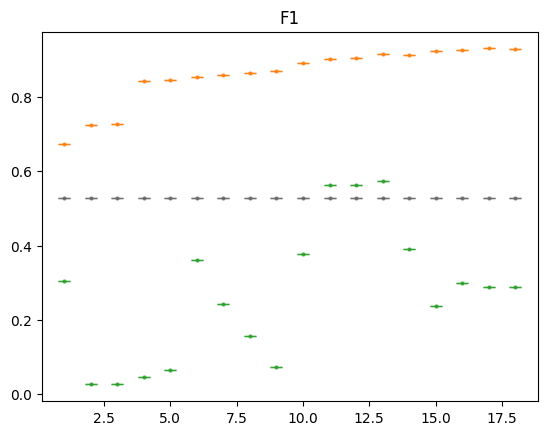

In [190]:
metric = 'f1'
for i in list(acuracy_across_mb.keys())[:-1]:
    plt.errorbar(
    i,
    acuracy_across_mb[i]['cv mean'][metric],
    yerr=acuracy_across_mb[i]['cv std'][metric],
    fmt='-o',
    color="tab:orange",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test mean'][metric],
    yerr=acuracy_across_mb[i]['test std'][metric],
    fmt='-o',
    color="tab:green",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
    plt.errorbar(
    i,
    acuracy_across_mb[i]['test baseline mean'][metric],
    yerr=acuracy_across_mb[i]['test baseline std'][metric],
    fmt='-o',
    color="dimgray",
    capsize=4,
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
  #  label=label
)
plt.title("F1")

In [191]:
cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if TAX_LEVEL == "domain":
        taxa_group_names_train = None
    else:    
        taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]
    indices = [i for i, val in enumerate(X_column_names) if val in aver_m_names]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(
                X_val_train[:, indices],
                y_label_train,
                range_ids,
                sample_weights,
                X_val_test[:, indices],
                y_label_test,
                taxonomy_labels=taxa_group_names_train
            )
            
            # (do something with dict_res_two_class, e.g. save results)
            
        except Exception as e:
            print(f"Skipping iteration {indices} due to error: {e}")
            continue
        # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = 50
    y_label_test_bin  = (y_label_test.squeeze() > 45).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    
    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()

    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)


    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()
    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std}

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_aver_shap.csv")

print(df)

Processing 0 split...
            cv mean  cv std  test mean  test std  test baseline mean  \
accuracy   0.920413     0.0   0.509804       0.0            0.500000   
precision  0.936477     0.0   0.473684       0.0            0.562092   
recall     0.927108     0.0   0.121622       0.0            0.500000   
f1         0.931769     0.0   0.193548       0.0            0.529231   
rmse       5.002393     0.0  15.533931       0.0           10.831813   
r2         0.850608     0.0  -1.056650       0.0            0.000000   
rmse_low   5.235957     0.0   8.476339       0.0                 NaN   
r2_low     0.271508     0.0  -0.974166       0.0                 NaN   
rmse_high  4.828928     0.0  20.547684       0.0                 NaN   
r2_high    0.344582     0.0 -12.543016       0.0                 NaN   

           test baseline std  
accuracy                 0.0  
precision                0.0  
recall                   0.0  
f1                       0.0  
rmse                     0.0  

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [192]:
cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"Processing {split_id} split...")
  #  print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    if TAX_LEVEL == "domain":
        taxa_group_names_train = None
    else:    
        taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]

    mbs = all_shap_lists_dict_with_res[split_id]['MB']
    indices = [i for i, val in enumerate(X_column_names) if val in mbs]
    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train[:, indices], y_label_train, range_ids, sample_weights, X_val_test[:, indices], y_label_test, taxonomy_labels=taxa_group_names_train)
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = 50
    y_label_test_bin  = (y_label_test.squeeze() > 50).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    
    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()

    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)


    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > 50).squeeze()
    mask_low = (y_true < 50).squeeze()
    
    # Compute metrics for y_true > 45
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < 45
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std}

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['accuracy', 'precision', 'recall', 'f1', 'rmse', 'r2', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics_on_individ_shap.csv")

print(df)

Processing 0 split...
            cv mean  cv std  test mean  test std  test baseline mean  \
accuracy   0.920413     0.0   0.509804       0.0            0.500000   
precision  0.936477     0.0   0.473684       0.0            0.483660   
recall     0.927108     0.0   0.121622       0.0            0.500000   
f1         0.931769     0.0   0.193548       0.0            0.491694   
rmse       5.002393     0.0  15.533931       0.0           10.831813   
r2         0.850608     0.0  -1.056650       0.0            0.000000   
rmse_low   5.235957     0.0   8.476339       0.0                 NaN   
r2_low     0.271508     0.0  -0.974166       0.0                 NaN   
rmse_high  4.828928     0.0  20.547684       0.0                 NaN   
r2_high    0.344582     0.0 -12.543016       0.0                 NaN   

           test baseline std  
accuracy                 0.0  
precision                0.0  
recall                   0.0  
f1                       0.0  
rmse                     0.0  

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

##  Noise tests

In [12]:
def sample_exp(mean):
    sample = np.random.exponential(scale=mean)  # scale = 1/λ
    return sample

def sample_unif(mean):
    sample = np.random.uniform(0, 2*mean)
    return sample

def sample_gamma(mean):#(shape, scale):
    scale = 0.5
    shape = mean/scale
    sample = np.random.gamma(shape, scale)
    return sample    

In [13]:
def augment_data_with_noise(X_val_train, y_label_train, n_clones, mean_fp, mean_fn, noise_type=None, filename=None):
    # Start with the original data as lists
    X_augmented_list = [X_val_train]
    y_augmented_list = [y_label_train]

    if n_clones == 0:
        return X_val_train.clone(), y_label_train.clone()

    n_rows, _ = X_val_train.shape
    for i in range(n_rows):   
        genome = X_val_train[i]
        label = y_label_train[i]
        for _ in range(n_clones):

            # Sample FP/FN rates based on noise_type
            if noise_type == "exp":
                fp_rate_sampled = sample_exp(mean_fp)
                fn_rate_sampled = sample_exp(mean_fn)
            elif noise_type == "gamma":  
                fp_rate_sampled = sample_gamma(mean_fp)
                fn_rate_sampled = sample_gamma(mean_fn)
            elif noise_type == "unif":     
                fp_rate_sampled = sample_unif(mean_fp)
                fn_rate_sampled = sample_unif(mean_fn) 
            else:
                fp_rate_sampled = mean_fp
                fn_rate_sampled = mean_fn

            # Apply noise
            genome_noisy = apply_noise(genome, fp_rate=fp_rate_sampled, fn_rate=fn_rate_sampled)
            
            # Append to lists
            X_augmented_list.append(genome_noisy.unsqueeze(0))
            y_augmented_list.append(label.unsqueeze(0))

    # Stack / concatenate once at the end
    X_augmented = torch.cat(X_augmented_list, dim=0)
    y_augmented = torch.cat(y_augmented_list, dim=0)

    # Shuffle the augmented dataset
    idx = torch.randperm(len(X_augmented))
    X_augmented, y_augmented = X_augmented[idx], y_augmented[idx]

    return X_augmented, y_augmented


In [14]:
import torch

def apply_noise(genome, fp_rate, fn_rate):
    genome_noisy = genome.float().clone()

    # False negatives (multiple hits per count, Poisson distributed)
    losses = torch.poisson(genome.float() * fn_rate)
    genome_noisy = torch.clamp(genome_noisy - losses.int(), min=0)

    # False positives (Poisson noise added to zeros only)
    fp_add = torch.zeros_like(genome)
    zero_mask = genome > -1
    fp_add[zero_mask] = torch.poisson(torch.full((zero_mask.sum(),), fp_rate))
    genome_noisy = genome_noisy + fp_add

    return genome_noisy

In [15]:
import torch

def flip_with_fractional_noise(X: torch.Tensor, fp_rate: float, fn_rate: float,
                               noise_std = 0.3, hard_fn_flag = False):
    X_noisy = X.float().clone()
    n_rows, _ = X_noisy.shape
    for i in range(n_rows):
        # False negatives: subtract (1 + noise) from fraction of positives
        pos_idx = torch.nonzero(X[i] > 0).flatten()
        n_fn = int(round(fn_rate * len(pos_idx)))

        if n_fn > 0:
            fn_idx = pos_idx[torch.randperm(len(pos_idx))[:n_fn]]
            noise = torch.randn(len(fn_idx)) * noise_std
            if hard_fn_flag == False:
                X_noisy[i, fn_idx] -= 1#(1.0 + noise)
            else:
                X_noisy[i, fn_idx] = 0 

        # False positives: add (1 + noise) to fraction of zeros
        zero_idx = torch.nonzero(X[i] > -1).flatten()
        n_fp = int(round(fp_rate * len(zero_idx)))
        if n_fp > 0:
            fp_idx = zero_idx[torch.randperm(len(zero_idx))[:n_fp]]
            noise = torch.randn(len(fp_idx)) * noise_std
            X_noisy[i, fp_idx] += 1 #(1.0 + noise)

    # Clamp to ensure no negatives
    X_noisy = torch.clamp(X_noisy, min=0.0)    

    return X_noisy


## Noize tolerance of the original model

In [5]:
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor

from tqdm import tqdm
import numpy as np
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.utils.class_weight import compute_class_weight
import subprocess

from utils.utils import train_xgboost, calculate_aver_std
from sklearn.metrics import mean_squared_error,r2_score

def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
       # predictor=predictor,
        n_jobs=-1
    )


def make_xgb_regressor(tree_method="auto"):
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1,
        objective="reg:squarederror",  # standard regression
        eval_metric="rmse"              # optional
    )  

In [6]:
def label_ogt_range(y,high_thresh=45):
    labels = []
    for val in y:
        if val < high_thresh:
            labels.append('low')
        else:
            labels.append('high')
    return np.array(labels)

In [7]:
use_gpu = torch.cuda.is_available()
tree_method = "gpu_hist" if use_gpu else "hist"
predictor = "gpu_predictor" if use_gpu else "auto"

In [8]:
cog_remov_add_accuracies = defaultdict(dict)

device = DEVICE
cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]

noise_std = 0.3
temp_bound = 45

# -----------------------
# Train once per split_id
# -----------------------
trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]


    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    # 1. Gating model
    gating_model_with_noise = make_xgb()
    gating_model_with_noise.fit(X_val_train, range_ids, sample_weight=sample_weights)

    # Convert to numpy
    X_train_np = X_val_train.cpu().numpy()
    y_train_np = y_label_train.cpu().numpy().flatten()
    
    # Right and left regressors
    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    model_low_with_noise = make_xgb_regressor()
    model_high_with_noise = make_xgb_regressor()
    model_low_with_noise.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high_with_noise.fit(X_train_np[high_mask], y_train_np[high_mask])

    trained_models[split_id] = (gating_model_with_noise, model_low_with_noise, model_high_with_noise)

Training splits:   0%|                                                                                                     | 0/30 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [20]:
def eval_trained_models_on_noisy_data_classif_and_regress(trained_models, hard_fn_flag = False):
   # cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
   # cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]
    cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]
    cog_removal_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    
    cog_remov_add_accuracies = {}
    
    for rem_rate in tqdm(cog_removal_rates, desc="removal rates"):
        for add_rate in cog_adding_rates:#tqdm(cog_adding_rates, desc=f"adding rates (rem={rem_rate:.2f})", leave=False):
            
            mcc_arr, mcc_accuracy, mcc_balanced_accuracy = [], [], []
            mcc_precision, mcc_recall, mcc_f1 = [], [], []
            rmse_arr, r2_arr = [], []
            
            for split_id, models in trained_models.items():
                classifier, regressor_low, regressor_high = models
                X_val_test  = all_splits_dict[split_id]["X_test"]
                y_label_test = all_splits_dict[split_id]["y_test"]

                range_labels = label_ogt_range(y_label_test)
                le = LabelEncoder()
                range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
                label_to_int = {'low': 0, 'high': 1}
                range_ids = np.vectorize(label_to_int.get)(range_labels)
    
                # Apply noise
                hard_fn_flag = True
                
                X_val_test_noisy = flip_with_fractional_noise(
                    X_val_test.cpu(), add_rate, rem_rate, noise_std , hard_fn_flag = hard_fn_flag)
                
                # X_val_test_noisy = torch.empty((0, X_val_test.shape[1]), dtype=X_val_test.dtype)
                # n_rows, _ = X_val_test.shape
                # for i in range(n_rows):
                #     noisy_genome = apply_noise(X_val_test[i], fp_rate=add_rate, fn_rate=rem_rate)
                #     noisy_genome = noisy_genome.unsqueeze(0)
                #     X_val_test_noisy = torch.cat([X_val_test_noisy, noisy_genome.clone()], dim=0)

                #TODO: add weights

                # Predictions & metrics
                classifier_pred = classifier.predict(X_val_test_noisy)
                classifier_probs = classifier.predict_proba(X_val_test_noisy)
                
                mcc_arr.append(matthews_corrcoef(range_ids, classifier_pred))
                mcc_accuracy.append(accuracy_score(range_ids, classifier_pred))
                mcc_balanced_accuracy.append(balanced_accuracy_score(range_ids, classifier_pred))
                mcc_precision.append(precision_score(range_ids, classifier_pred, zero_division=0))
                mcc_recall.append(recall_score(range_ids, classifier_pred, zero_division=0))
                mcc_f1.append(f1_score(range_ids, classifier_pred, zero_division=0))

                # Final prediction
                pred_low  = regressor_low.predict(X_val_test_noisy)
                pred_high  = regressor_high.predict(X_val_test_noisy)

                final_pred = (classifier_probs[:, 0]  * pred_low +classifier_probs[:, 1] * pred_high)

                rmse_arr.append(np.sqrt(mean_squared_error(y_label_test.cpu(), final_pred)))
                r2_arr.append(r2_score(y_label_test.cpu(), final_pred))


            # Save aggregated metrics
            cog_remov_add_accuracies[(rem_rate, add_rate)] = {
                "mcc": (np.mean(mcc_arr), np.std(mcc_arr)),
                "accuracy": (np.mean(mcc_accuracy), np.std(mcc_accuracy)),
                "balanced_accuracy": (np.mean(mcc_balanced_accuracy), np.std(mcc_balanced_accuracy)),
                "precision": (np.mean(mcc_precision), np.std(mcc_precision)),
                "recall": (np.mean(mcc_recall), np.std(mcc_recall)),
                "f1": (np.mean(mcc_f1), np.std(mcc_f1)),
                "rmse": (np.mean(rmse_arr), np.std(rmse_arr)),
                "r2": (np.mean(r2_arr), np.std(r2_arr))
            }
    return cog_remov_add_accuracies

In [21]:
cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data_classif_and_regress(trained_models, hard_fn_flag = True)

removal rates: 100%|██████████████████████████████████████████████████████| 11/11 [47:50<00:00, 260.92s/it]


In [9]:
def plot_one_accur_measure(ax, accuracy_measure, cog_remov_add_accuracies, alpha=1):
    cog_remov_add_accuracies_one_measure = defaultdict()
    for key in cog_remov_add_accuracies.keys():
        cog_remov_add_accuracies_one_measure[key] = cog_remov_add_accuracies[key][accuracy_measure]
    
    rem_rates = sorted(set(k[0] for k in cog_remov_add_accuracies_one_measure.keys()))
    add_rates = sorted(set(k[1] for k in cog_remov_add_accuracies_one_measure.keys()))
    
    cmap = plt.cm.tab10
    colors = [cmap(i / (len(rem_rates)-1)) for i in range(len(rem_rates))]

    for i, ar in enumerate(add_rates):
        means = []
        stds = []
        rem_rate_values = []
        for rr in rem_rates:
            key = (rr, ar)
            if key in cog_remov_add_accuracies_one_measure:
                mean, std = cog_remov_add_accuracies_one_measure[key]
                means.append(mean)
                stds.append(std)
                rem_rate_values.append(rr)
        ax.errorbar(rem_rate_values, means, yerr=stds, label=f"FP={ar}", marker='o', capsize=3, linestyle='-', color=colors[i], alpha=alpha)
    
    ax.set_xlabel("False negative rate", fontsize=FONTSIZE)
    ax.set_ylabel(accuracy_measure, fontsize=FONTSIZE)
    ax.legend()


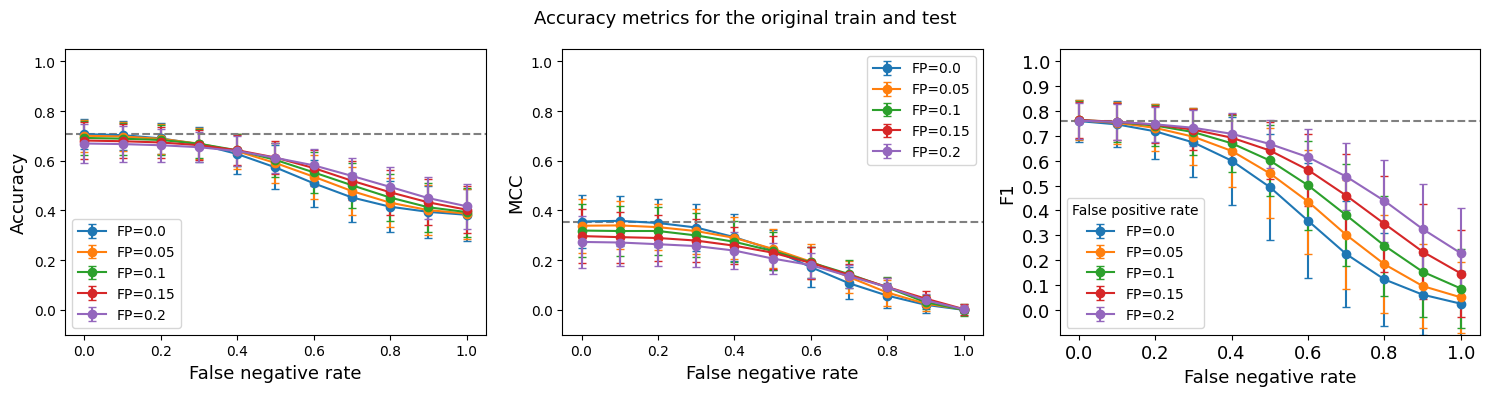

In [23]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(15,4))
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models)
axes[0].set_ylabel("Accuracy", fontsize=FONTSIZE)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
plt.xticks(fontsize=FONTSIZE)
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
axes[0].set_ylim([-0.1,1.05])

plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models)
axes[1].set_ylabel("MCC", fontsize=FONTSIZE)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
#plt.legend(title="False positive rate")
plt.xticks(fontsize=FONTSIZE)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
axes[1].set_ylim([-0.1,1.05])

plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models)
fig.suptitle("Accuracy metrics across noise levels", fontsize=16)
plt.xlabel("False negative rate", fontsize=FONTSIZE) #(1→0)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylabel("F1", fontsize=FONTSIZE)
plt.legend(title="False positive rate")
axes[2].set_ylim([-0.1,1.05])

plt.suptitle(f"Accuracy metrics for the original train and test", fontsize=FONTSIZE)    

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/accur_fp_fn.svg", format="svg")


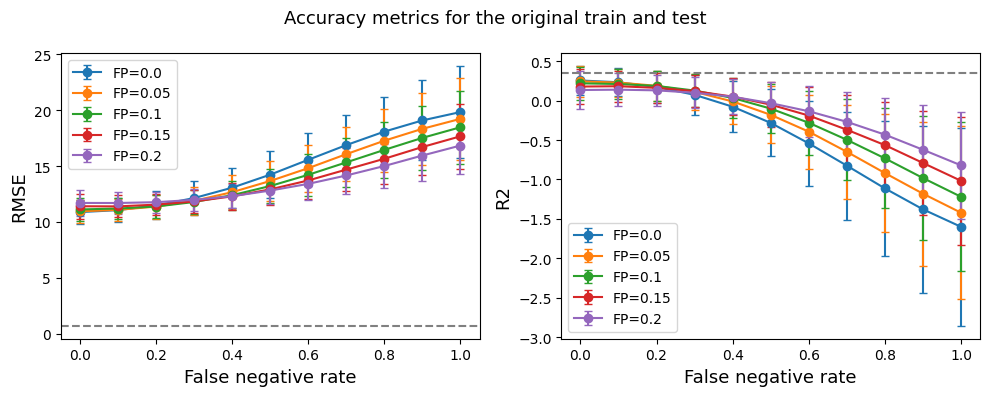

In [28]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,2, figsize=(10,4))
plot_one_accur_measure(axes[0], "rmse", cog_remov_add_accuracies_orig_models)
axes[0].set_ylabel("RMSE", fontsize=FONTSIZE)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
#plt.xticks(fontsize=FONTSIZE)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
#axes[0].set_ylim([-0.1,1.05])

plot_one_accur_measure(axes[1], "r2", cog_remov_add_accuracies_orig_models)
axes[1].set_ylabel("R2", fontsize=FONTSIZE)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
#plt.legend(title="False positive rate")
#plt.xticks(fontsize=FONTSIZE)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
#axes[1].set_ylim([-0.1,1.05])

plt.suptitle(f"Accuracy metrics for the original train and test", fontsize=FONTSIZE)    

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/accur_fp_fn.svg", format="svg")


In [10]:
def plot_model_groups(noise_increase_accuracy_one_metric, ax):
    data = []
    for (fp, fn), (mean, std) in noise_increase_accuracy_one_metric.items():
        data.append([fp, fn, mean, std])
    df = pd.DataFrame(data, columns=["FP", "FN", "Mean", "Std"])
    
    pivot = df.pivot(index="FP", columns="FN", values="Mean")
    pivot = pivot.astype(float) 
    mask = pivot.isna() 
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.0, vmax=1, mask=mask, ax=ax, cbar=False)

In [11]:
import os
import joblib

def read_and_evaluate_models_for_x_and_sigma(x_noisy_samples, noise_type, metric, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = 0.3, hard_fn_flag = None):
    mn_fn_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
    mn_fp_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
    # mn_fp_arr = [0.0, 0.05, 0.1, 0.15, 0.2]
    # mn_fn_arr = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    mean_rem_add_rates_tuples = [(add, rem) for add in mn_fp_arr for rem in mn_fn_arr]
    mean_rem_add_rates_tuples
    
    noise_increase_accuracy = {}
    for i in tqdm(range(len(mean_rem_add_rates_tuples)), desc="Processing noise rates..."):    
        (fp_rate_mean, fn_rate_mean) = mean_rem_add_rates_tuples[i]
        noise_rates = (fp_rate_mean, fn_rate_mean)

        filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
    
       # filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_sigma_fp_{sigma_fp}_sigma_fn_{sigma_fn}_x_{x_noisy_samples}.pkl"
        filepath = f"{OUTPUT_DIRECTORY}/trained_models/{filename}"
        metrics_accum = {key: [] for key in ["mcc", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "rmse", "r2"]}
        if os.path.exists(filepath):
            loaded_models_dict = joblib.load(filepath)
            
            for split_id in range(3):#all_splits_dict.keys(): #all_splits_dict.keys()
                trained_model = loaded_models_dict[split_id]
                classifier, regressor_low, regressor_high = trained_model
                
                X_val_test = all_splits_dict[split_id]["X_test"]
                y_label_test = all_splits_dict[split_id]["y_test"]

                # Convert to numpy
                y_train_np = y_label_test.cpu().numpy().flatten()
                range_labels = label_ogt_range(y_label_test)
                le = LabelEncoder()
                range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
                label_to_int = {'low': 0, 'high': 1}
                range_ids = np.vectorize(label_to_int.get)(range_labels)
                
                if clean_test_flag == True:
                    classifier_pred = classifier.predict(X_val_test)
                    classifier_probs = classifier.predict_proba(X_val_test)

                    # Final prediction
                    pred_low  = regressor_low.predict(X_val_test)
                    pred_high  = regressor_high.predict(X_val_test)
                    final_pred = (classifier_probs[:, 0]  * pred_low +classifier_probs[:, 1] * pred_high)
                    
                else:  
                    # Apply noise
                    X_val_test_noisy = flip_with_fractional_noise(
                        X_val_test.cpu(), add_rate, rem_rate, noise_std , hard_fn_flag = hard_fn_flag)
                    classifier_pred = classifier.predict(X_val_test_noisy)
                    classifier_probs = classifier.predict_proba(X_val_test_noisy)

                    # Final prediction
                    pred_low  = regressor_low.predict(X_val_test_noisy)
                    pred_high  = regressor_high.predict(X_val_test_noisy)
                    final_pred = (classifier_probs[:, 0]  * pred_low +classifier_probs[:, 1] * pred_high)

                metrics_accum["mcc"].append(matthews_corrcoef(range_ids, classifier_pred))
                metrics_accum["accuracy"].append(accuracy_score(range_ids, classifier_pred))
                metrics_accum["balanced_accuracy"].append(balanced_accuracy_score(range_ids, classifier_pred))
                metrics_accum["precision"].append(precision_score(range_ids, classifier_pred, zero_division=0))
                metrics_accum["recall"].append(recall_score(range_ids, classifier_pred, zero_division=0))
                metrics_accum["f1"].append(f1_score(range_ids, classifier_pred, zero_division=0))
                metrics_accum["rmse"].append(np.sqrt(mean_squared_error(y_label_test.cpu(), final_pred))),
                metrics_accum["r2"].append(r2_score(y_label_test.cpu(), final_pred))
            
            test_accuracy_scores = {k: [np.mean(v), np.std(v)] for k,v in metrics_accum.items()}    
        else:
            test_accuracy_scores = {k: [None, None] for k,v in metrics_accum.items()}
        noise_increase_accuracy[tuple(noise_rates)] = test_accuracy_scores
    
    noise_increase_accuracy_one_metric = {}
    for key in noise_increase_accuracy.keys():
        noise_increase_accuracy_one_metric[key] = noise_increase_accuracy[key] [metric]
        
  #  areas_mn_std=areas_across_fps(noise_increase_accuracy_one_metric)     
    
        
    return noise_increase_accuracy_one_metric#, areas_mn_std

Processing noise rates...: 100%|████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 7979.02it/s]


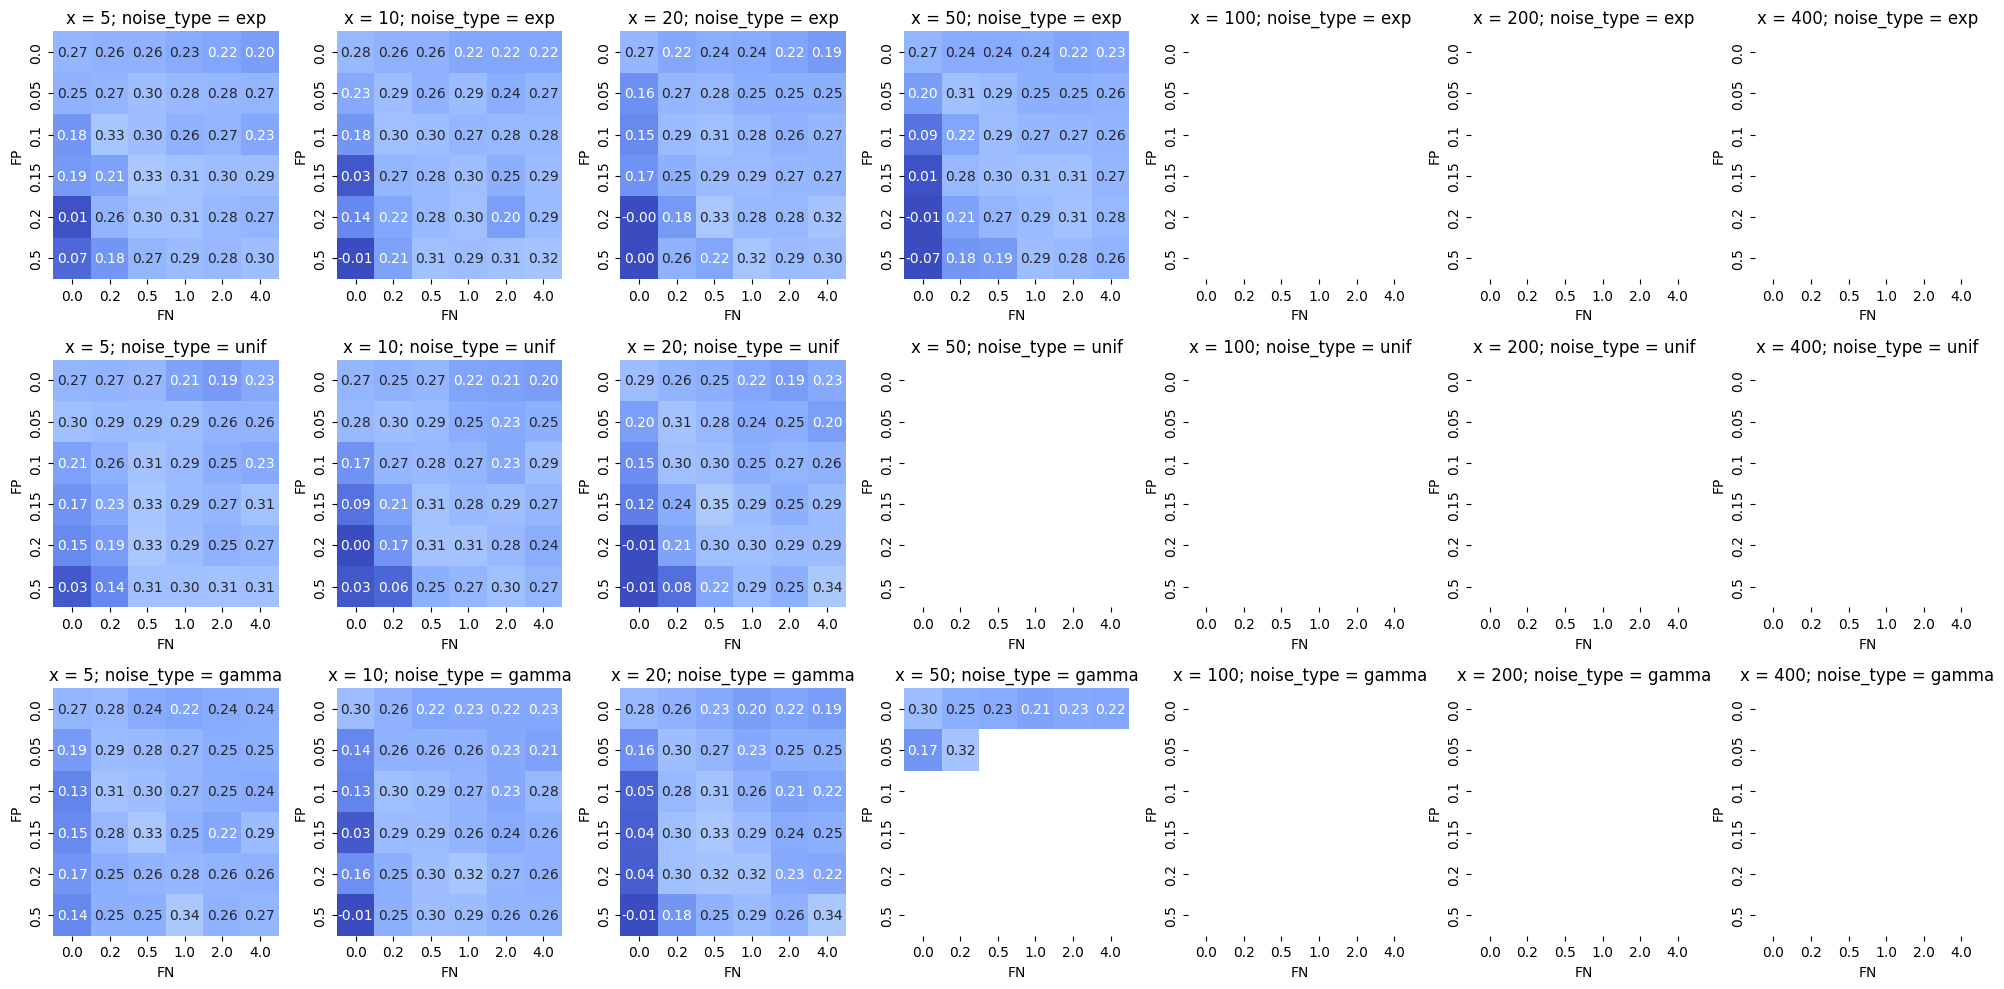

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sigma_range = [0.0, 0.02, 0.1, 0.5, 5.0]
x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'mcc'

noise_type_range = ["exp", "unif", "gamma"]


areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric= read_and_evaluate_models_for_x_and_sigma(x, noise_type, metric, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_ylabel("FP")
        ax.set_xlabel("FN")
plt.tight_layout()        

Processing noise rates...: 100%|█████████████████████████████████████████| 36/36 [00:00<00:00, 9404.27it/s]


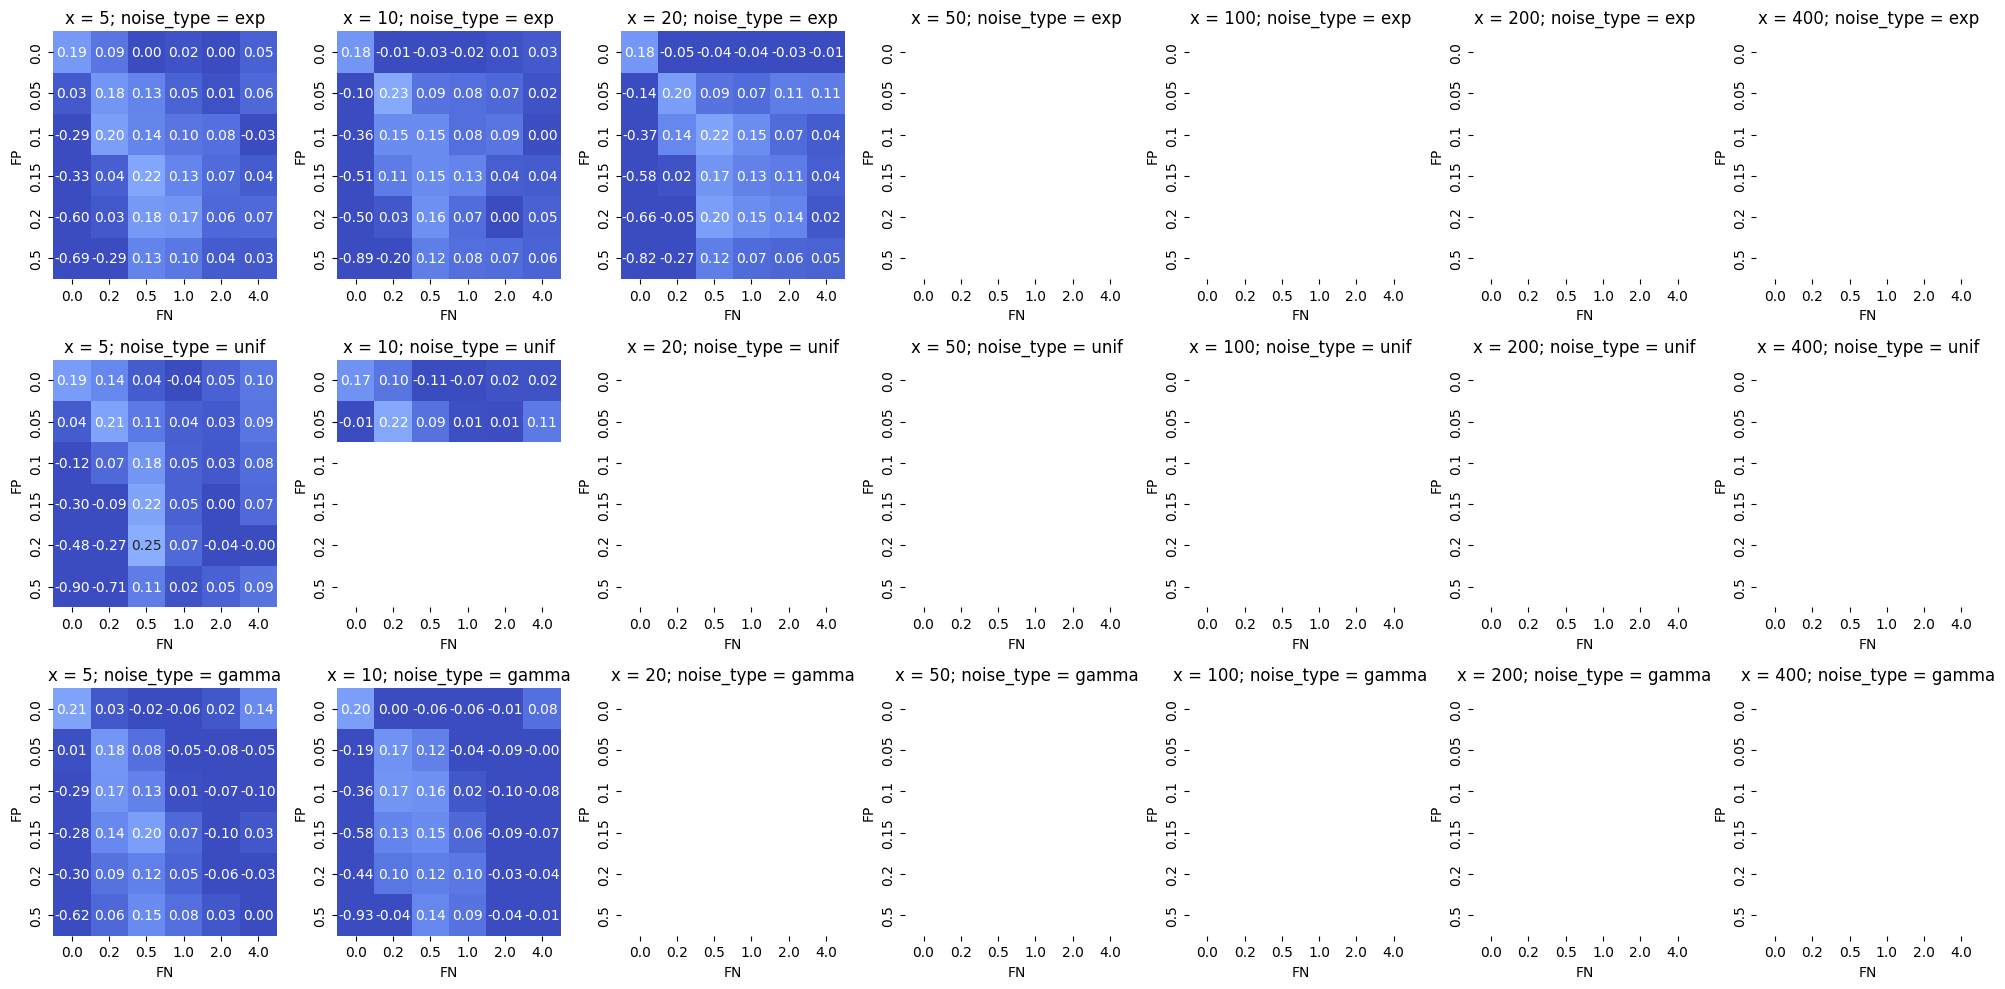

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sigma_range = [0.0, 0.02, 0.1, 0.5, 5.0]
x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'r2'

noise_type_range = ["exp", "unif", "gamma"]


areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric= read_and_evaluate_models_for_x_and_sigma(x, noise_type, metric, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_ylabel("FP")
        ax.set_xlabel("FN")
plt.tight_layout()        

Processing noise rates...: 100%|█████████████████████████████████████████| 36/36 [00:00<00:00, 9357.64it/s]


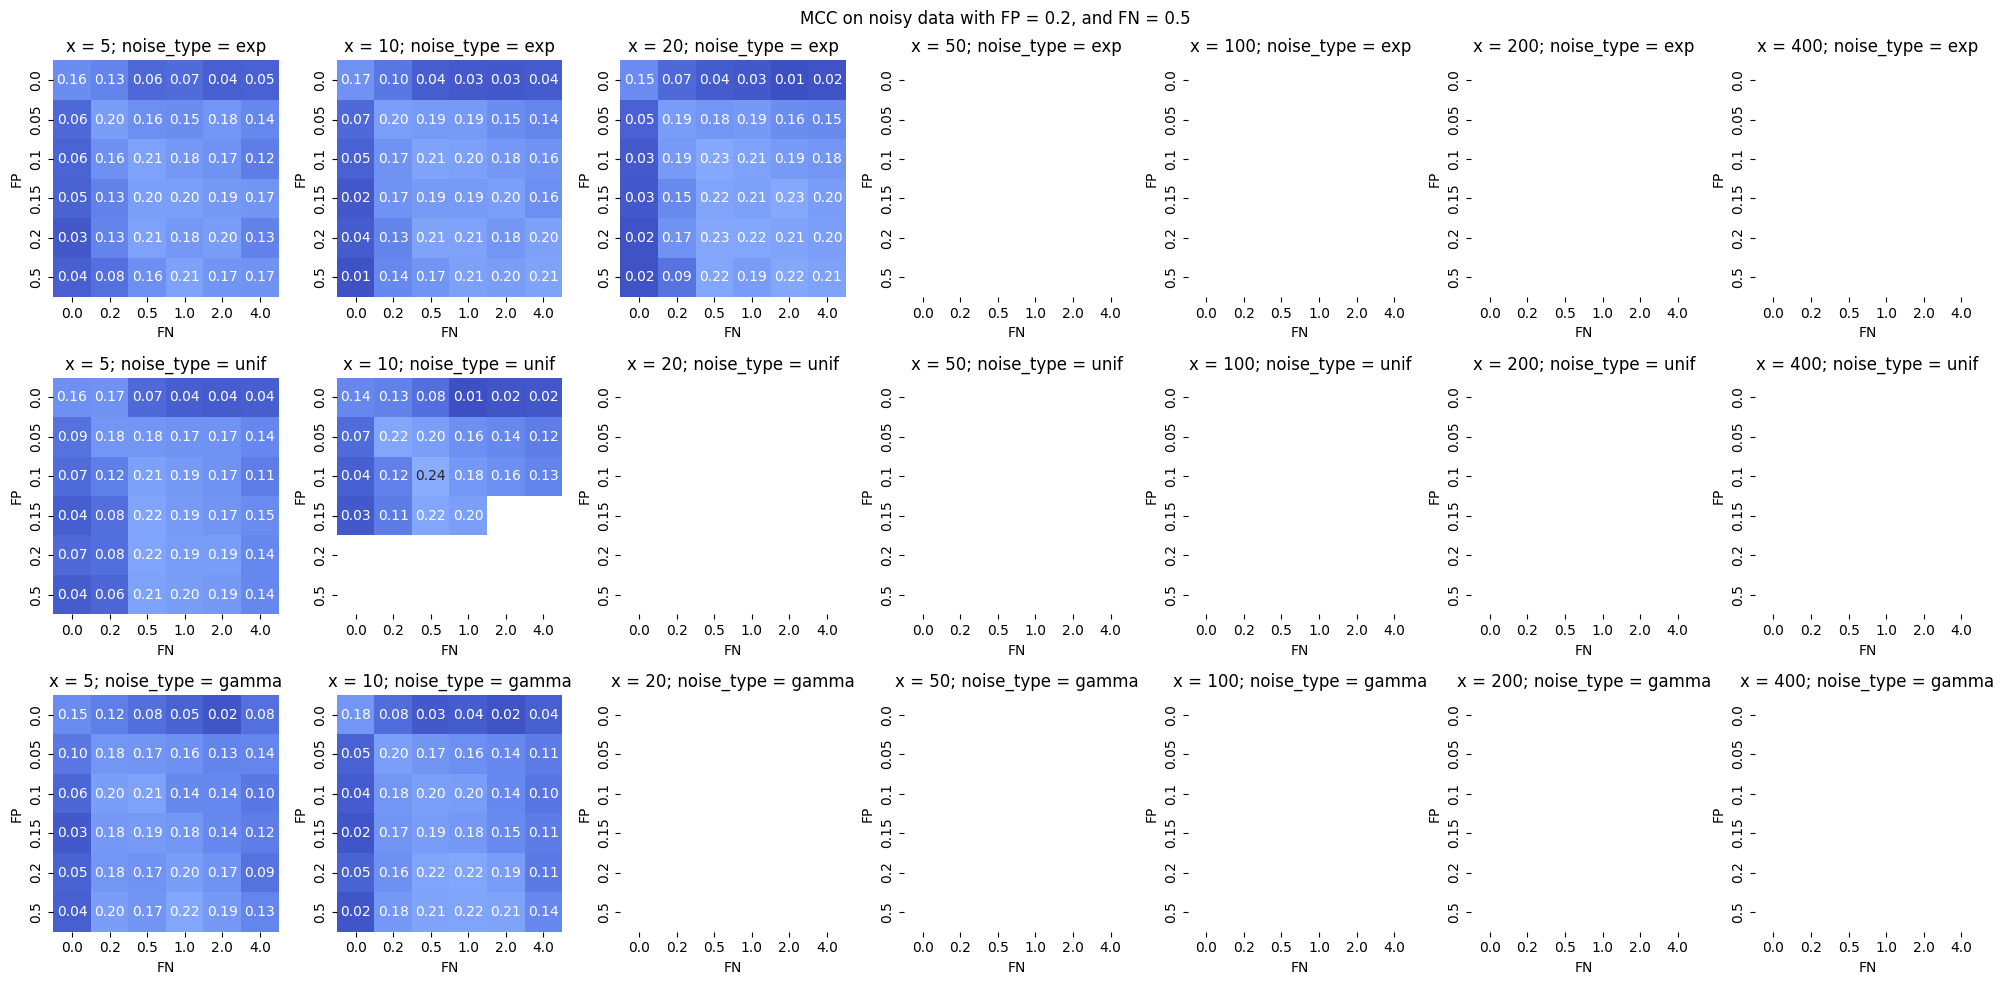

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'mcc'

noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.2
test_fn = 0.5

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(x, noise_type, metric, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
      #  areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_ylabel("FP")
        ax.set_xlabel("FN")
plt.suptitle(f"MCC on noisy data with FP = {test_fp}, and FN = {test_fn}")       

plt.tight_layout()    

Processing noise rates...: 100%|███████████████████████████████████████████| 36/36 [03:32<00:00,  5.91s/it]


ValueError: too many values to unpack (expected 2)

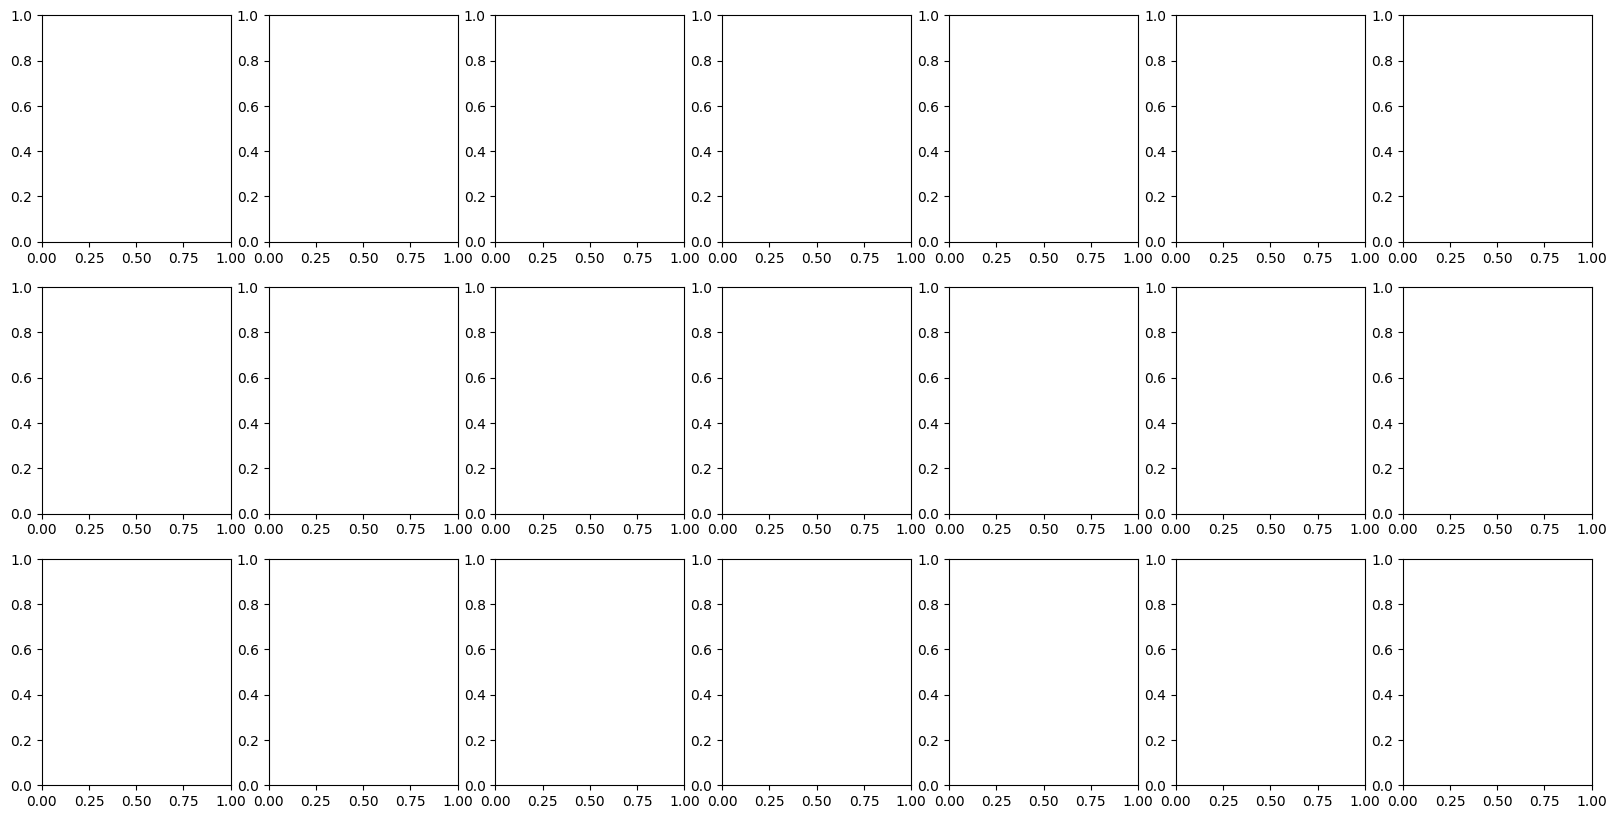

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'r2'

noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.2
test_fn = 0.5

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric, areas_mn_std = read_and_evaluate_models_for_x_and_sigma(x, noise_type, metric, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
        areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_ylabel("FP")
        ax.set_xlabel("FN")
plt.suptitle(f"MCC on noisy data with FP = {test_fp}, and FN = {test_fn}")       

plt.tight_layout()    

In [ ]:
def eval_trained_models_on_noisy_data(trained_models, hard_fn_flag = False):
   # cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
   # cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]
    cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]
    cog_removal_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    cog_remov_add_accuracies = {}
    
    for rem_rate in tqdm(cog_removal_rates, desc="removal rates"):
        for add_rate in cog_adding_rates:#tqdm(cog_adding_rates, desc=f"adding rates (rem={rem_rate:.2f})", leave=False):
            
            mcc_arr, mcc_accuracy, mcc_balanced_accuracy = [], [], []
            mcc_precision, mcc_recall, mcc_f1 = [], [], []
            mcc_r2, mcc_rmse= [], []
            
            for split_id in loaded_models_dict.keys():
                trained_model = loaded_models_dict[split_id]
                classifier, regressor_low, regressor_high = trained_model
                
                X_val_test  = all_splits_dict[split_id]["X_test"]
                y_label_test = all_splits_dict[split_id]["y_test"]

                # Convert to numpy
                y_train_np = y_label_test.cpu().numpy().flatten()
                range_labels = label_ogt_range(y_label_test)
                le = LabelEncoder()
                range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
                label_to_int = {'low': 0, 'high': 1}
                range_ids = np.vectorize(label_to_int.get)(range_labels)
                
                
                # Apply noise
                X_val_test_noisy = flip_with_fractional_noise(
                    X_val_test.cpu(), add_rate, rem_rate, noise_std , hard_fn_flag = hard_fn_flag)
                 
                # Apply noise
                X_val_test_noisy = flip_with_fractional_noise(
                X_val_test.cpu(), add_rate, rem_rate, noise_std , hard_fn_flag = hard_fn_flag)
                classifier_pred = classifier.predict(X_val_test_noisy)
                classifier_probs = classifier.predict_proba(X_val_test_noisy)

                # Final prediction
                pred_low  = regressor_low.predict(X_val_test_noisy)
                pred_high  = regressor_high.predict(X_val_test_noisy)
                final_pred = (classifier_probs[:, 0]  * pred_low +classifier_probs[:, 1] * pred_high)
                
                # Predictions & metrics
                mcc_arr.append(matthews_corrcoef(range_ids, classifier_pred))
                mcc_accuracy.append(accuracy_score(range_ids, classifier_pred))
                mcc_balanced_accuracy.append(balanced_accuracy_score(range_ids, classifier_pred))
                mcc_precision.append(precision_score(range_ids, classifier_pred, zero_division=0))
                mcc_recall.append(recall_score(range_ids, classifier_pred, zero_division=0))
                mcc_f1.append(f1_score(range_ids, classifier_pred, zero_division=0))

                mcc_rmse.append(np.sqrt(mean_squared_error(y_label_test.cpu(), final_pred))),
                mcc_r2.append(r2_score(y_label_test.cpu(), final_pred))
                                             
            # Save aggregated metrics
            cog_remov_add_accuracies[(rem_rate, add_rate)] = {
                "mcc": (np.mean(mcc_arr), np.std(mcc_arr)),
                "accuracy": (np.mean(mcc_accuracy), np.std(mcc_accuracy)),
                "balanced_accuracy": (np.mean(mcc_balanced_accuracy), np.std(mcc_balanced_accuracy)),
                "precision": (np.mean(mcc_precision), np.std(mcc_precision)),
                "recall": (np.mean(mcc_recall), np.std(mcc_recall)),
                "f1": (np.mean(mcc_f1), np.std(mcc_f1)),
                "r2": (np.mean(mcc_r2), np.std(mcc_r2)),
                "rmse": (np.mean(mcc_rmse), np.std(mcc_rmse)),
            }
    return cog_remov_add_accuracies

In [ ]:
# Choose a model

# x = 5, 10, 20, 50, 100
#sigma = 0, 0.02, 0.1, 0.5, 5
#mn_fp_arr = [0.0, 0.05, 0.1, 0.15, 0.2]
#mn_fn_arr = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

x_noisy_samples = 10
fp_rate_mean = 0.1
fn_rate_mean = 0.5
noise_type = "exp"
#sigma_fp = sigma_fn = None#0.02

#filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_sigma_fp_{sigma_fp}_sigma_fn_{sigma_fn}_x_{x_noisy_samples}.pkl"
filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
#f"trained_models_unif_fp_{fp_rate_mean}_fn_{fn_rate_mean}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models/{filename}")

In [ ]:
#cog_remov_add_accuracies = eval_trained_models_on_noisy_data(trained_models, hard_fn_flag = True)
cog_remov_add_accuracies = eval_trained_models_on_noisy_data(loaded_models_dict, hard_fn_flag = True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(15,4))

plt.subplot(1, 3, 1)
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies)
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
plt.xlabel("False negative rate", fontsize=FONTSIZE) #(1→0)
plt.ylabel("Accuracy", fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
axes[0].set_ylim([-0.1,1.05])
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)


plt.subplot(1, 3, 2)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
plt.ylabel("MCC", fontsize=FONTSIZE)
#plt.legend(title="False positive rate")
plt.xticks(fontsize=FONTSIZE)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)

#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
axes[1].set_ylim([-0.1,1.05])

plt.subplot(1, 3, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)

plt.ylabel("F1", fontsize=FONTSIZE)
#plt.legend(title="False positive rate")

plt.xticks(fontsize=FONTSIZE)
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
axes[2].set_ylim([-0.1,1.05])
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/accur_measures_noise_fp_fn.svg", format="svg")
plt.suptitle(f"Accuracies for the models trained on the noisy data with mean FP = {fp_rate_mean}, mean FN = {fn_rate_mean}, noise_type = {noise_type}, x = {x_noisy_samples}", fontsize=FONTSIZE)    
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/accur_fp_fn.svg", format="svg")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,2, figsize=(15,4))

plt.subplot(1, 2, 1)
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies)
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies_orig_models, alpha=0.5)
plt.xlabel("False negative rate", fontsize=FONTSIZE) #(1→0)
plt.ylabel("R2", fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
#axes[0].set_ylim([-0.1,1.05])
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)


plt.subplot(1, 2, 2)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies_orig_models, alpha=0.5)
plt.ylabel("RMSE", fontsize=FONTSIZE)
#plt.legend(title="False positive rate")
plt.xticks(fontsize=FONTSIZE)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)

#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=FONTSIZE)
#axes[1].set_ylim([-0.1,1.05])


#plt.tight_layout()
plt.suptitle(f"Accuracies for the models trained on the noisy data with mean FP = {fp_rate_mean}, mean FN = {fn_rate_mean}, noise_type = {noise_type}, x = {x_noisy_samples}", fontsize=FONTSIZE)    
#plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/accur_fp_fn.svg", format="svg")


#### 2. PCA and tSNE projections of the training data (colors = temperature)

In this section, we visualize all points from our datasets by projecting them into 2D PCA, and tSNE spaces. This projections give us insights on the structure of the datasets. 

First, we visualize the points and color them with respect to their OGTs.

In [39]:
if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

In [40]:
# Concatenate train and test for the 2D visualization
y_label = torch.cat((y_train, y_test), dim=0)
X_val = torch.cat((X_train, X_test), dim=0)
if TAX_LEVEL != "random":
    taxa_group_names = taxa_group_names_train + taxa_group_names_test

In [41]:
FONTSIZE = 13

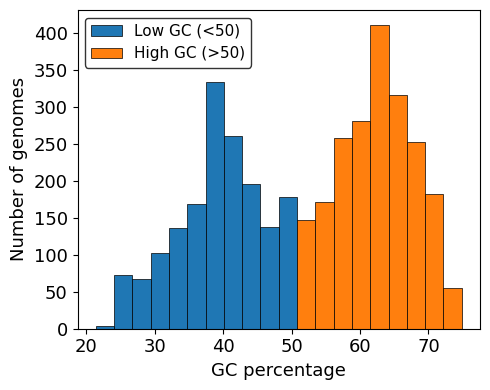

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

data = y_label.cpu().numpy()
threshold = 50
counts, bins = np.histogram(data, bins=20)

plt.figure(figsize=(5,4))

left_max_y = 0
right_max_y = 0

# Plot each bin individually
for i in range(len(bins) - 1):
    bin_center = (bins[i] + bins[i + 1]) / 2
    color = 'tab:blue' if bin_center < threshold else 'tab:orange'
    bar = plt.bar(bins[i], counts[i], width=bins[i + 1] - bins[i],
                  align='edge', color=color, edgecolor='black', linewidth=0.5)
    
    # Track max heights for annotation placement
    if bin_center < threshold:
        left_max_y = max(left_max_y, counts[i])
    else:
        right_max_y = max(right_max_y, counts[i])

# Add custom legend entries
meso_patch = mpatches.Patch(facecolor='tab:blue', label='Low GC (<50)', edgecolor='black', linewidth=0.5)
thermo_patch = mpatches.Patch(facecolor='tab:orange', label='High GC (>50)', edgecolor='black', linewidth=0.5)

# Add to legend
plt.legend(handles=[meso_patch, thermo_patch], fontsize=FONTSIZE - 2, edgecolor='black')

# Final formatting
plt.xlabel("GC percentage", fontsize=FONTSIZE)
plt.ylabel("Number of genomes", fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
plt.yticks(fontsize=FONTSIZE)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/data_distrib.svg", format="svg")



Shape of the projected data = (3734, 2)


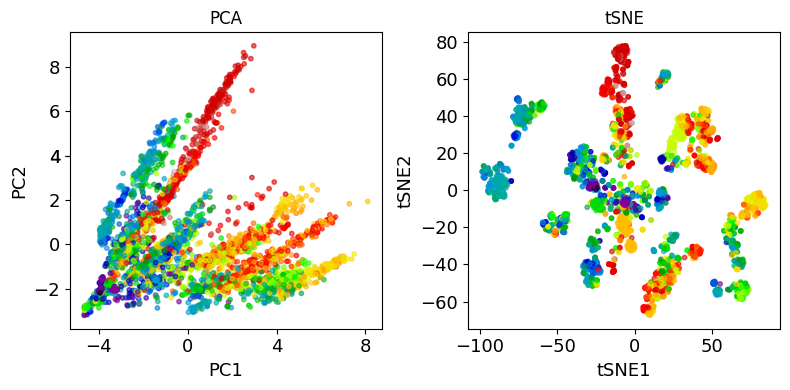

In [20]:
from utils.utils import pca_run_and_plot, tsne_plot

plt.figure(figsize=(8, 4))
X_train, y_train, X_test, y_test = X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu()
colorbar = False

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 10
pca_run_and_plot(X_val.cpu(), n_compon, y_label.cpu(), None, None, False, colorbar);
plt.xlabel("PC1", fontsize = FONTSIZE)
plt.ylabel("PC2", fontsize = FONTSIZE)
plt.xticks([-4, 0, 4, 8], fontsize = FONTSIZE)
plt.yticks([-2, 0, 2, 4, 4, 6, 8], fontsize = FONTSIZE)

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, y_label.cpu(), None, colorbar);
plt.xlabel("tSNE1", fontsize = FONTSIZE)
plt.ylabel("tSNE2", fontsize = FONTSIZE)
plt.xticks([-100, -50, 0, 50], fontsize = FONTSIZE)
plt.yticks([-60, -40, -20, 0, 20, 40, 60, 80], fontsize = FONTSIZE)

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_orig_phenot.svg", format="svg")
plt.show()

Shape of the projected data = (3734, 2)


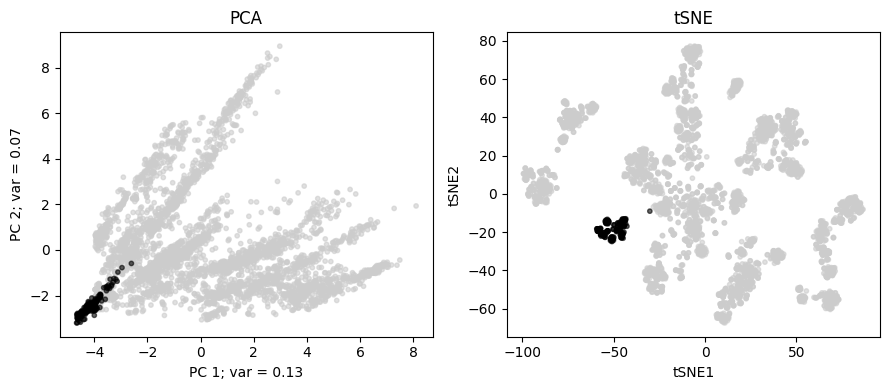

In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

if TAX_LEVEL != "random":
    plt.figure(figsize=(9, 4))
    
    # PCA space
    plt.subplot(1, 2, 1) 
    n_compon = 10
    colors = None
    category_names = taxa_group_names
    pca_run_and_plot(X_val.cpu(), n_compon, label_encoder.fit_transform(category_names),
                     category_names, colors);
    # t-SNE space
    plt.subplot(1, 2, 2) 
    tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, label_encoder.fit_transform(category_names));
    
    # Display the plots
    plt.tight_layout()  
    plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_all_feat.pdf", format="pdf")
    plt.show()

## Initial prediction

In [7]:
from utils.utils import train_xgboost, calculate_aver_std
from sklearn.metrics import mean_squared_error,r2_score
from feature_selection.feature_selection_utils import xgboost_train_accur, xgboost_accur_select_features
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, max_depth=8, learning_rate=0.05)

# Define the baseline (for all features) XGBoost accuracy
y_true_cv, y_pred_cv, y_pred_test, model  = train_xgboost(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu(), weights=None, model=model, taxonomy_labels=taxa_group_names_train) 

rmse_test = np.sqrt(mean_squared_error(y_test.cpu(), y_pred_test))
r2_test = r2_score(y_test.cpu(), y_pred_test)

rmse_cv = np.sqrt(mean_squared_error(y_true_cv, y_pred_cv))
r2_cv = r2_score(y_true_cv, y_pred_cv)

print(f"XGBoost baseline test RMSE (all features) = {rmse_test:.2f}, R2 = {r2_test:.2f}")
print(f"XGBoost baseline CV RMSE (all features) = {rmse_cv:.2f}, R2 = {r2_cv:.2f}")

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost baseline test RMSE (all features) = 12.84, R2 = -0.41
XGBoost baseline CV RMSE (all features) = 4.18, R2 = 0.90


/scratch/ipykernel_3197144/2695455758.py:23: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(y_true_cv, diff, marker='o', alpha = 0.1, c = "tab:blue", s=7, facecolor='none')
/scratch/ipykernel_3197144/2695455758.py:49: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(y_test.cpu(), diff, marker='o', alpha = 0.1, c = "tab:blue", s=7, facecolor='none')


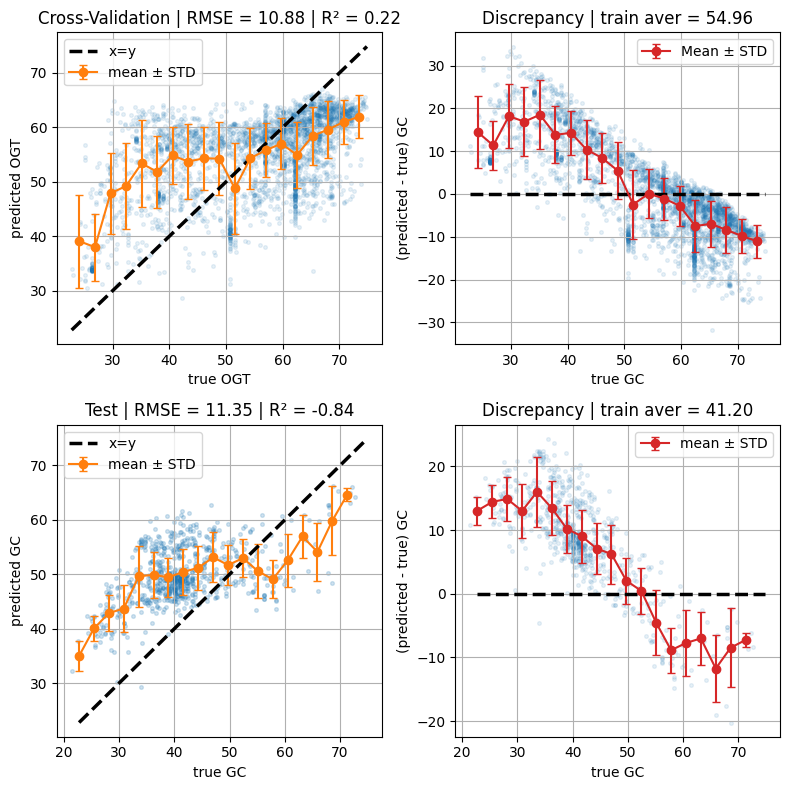

In [10]:
plt.figure(figsize=(8, 8))

num_bins = 20
min_temp = min(y_true_cv.squeeze())
max_temp = max(y_true_cv.squeeze())

# Cross-Validation: prediction vs actual
plt.subplot(2, 2, 1) 
plt.scatter(y_true_cv, y_pred_cv, marker='o', alpha = 0.1, c = "tab:blue", s=7)
bin_centers, mean_diff, std_diff = calculate_aver_std(y_true_cv.squeeze(), y_pred_cv.squeeze(), num_bins)
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:orange', capsize=3, label='mean ± STD')
plt.plot([min_temp,max_temp],[min_temp,max_temp], c = "black", label = "x=y", linestyle='--', linewidth=2.5) 
plt.xlabel("true OGT")
plt.ylabel("predicted OGT")
plt.title(f"Cross-Validation | RMSE = {rmse_cv:.2f} | R² = {r2_cv:.2f}")
plt.legend()
plt.grid(True)

# Cross-Validation: (prediction - actual)
plt.subplot(2, 2, 2) 
diff = [y_pred_cv[i] - y_true_cv[i] for i in range(len(y_true_cv))]
bin_centers, mean_diff, std_diff = calculate_aver_std(y_true_cv.squeeze(), np.array([x.item() for x in diff]), num_bins)
plt.scatter(y_true_cv, diff, marker='o', alpha = 0.1, c = "tab:blue", s=7, facecolor='none') 
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:red', capsize=3, label='Mean ± STD')
plt.plot([min_temp,max_temp],[0,0], c = "black", linestyle='--', linewidth=2.5) 
plt.xlabel("true GC")
plt.ylabel("(predicted - true) GC")
plt.title(f"Discrepancy | train aver = {mean_train:.2f}")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3) 
#y_true_cv, y_pred_cv, y_pred_test = train_xgboost(X_train, y_train, X_test, y_test)
plt.scatter(y_test.cpu(), y_pred_test, marker='o', alpha = 0.2, c = "tab:blue", s=7)
bin_centers_cv_old, mean_diff_cv_old, std_diff_cv_old = calculate_aver_std(y_test.cpu().squeeze(), y_pred_test.squeeze(), num_bins)
plt.errorbar(bin_centers_cv_old, mean_diff_cv_old, yerr=std_diff_cv_old, fmt='o-', color='tab:orange', capsize=3, label='mean ± STD')
plt.plot([min_temp,max_temp],[min_temp,max_temp], c = "black", label = "x=y", linestyle='--', linewidth=2.5) 
plt.xlabel("true GC")
plt.ylabel("predicted GC")
plt.title(f"Test | RMSE = {rmse_test:.2f} | R² = {r2_test:.2f}")
plt.grid(True)
plt.legend()

# Diff for full signal  
plt.subplot(2, 2, 4) 
y_test = y_test.cpu()
diff = [y_pred_test[i] - y_test[i] for i in range(len(y_pred_test))]
bin_centers_test_old, mean_diff_test_old, std_diff_test_old = calculate_aver_std(y_test.squeeze(), np.array([x.item() for x in diff]), num_bins)
plt.scatter(y_test.cpu(), diff, marker='o', alpha = 0.1, c = "tab:blue", s=7, facecolor='none')    
plt.errorbar(bin_centers_test_old, mean_diff_test_old, yerr=std_diff_test_old, fmt='o-', color='tab:red', capsize=3, label='mean ± STD')
plt.plot([min_temp,max_temp],[0,0], c = "black", linestyle='--', linewidth=2.5) 
plt.xlabel("true GC")
plt.ylabel("(predicted - true) GC")
plt.title(f"Discrepancy | train aver = {mean_test:.2f}")
plt.legend()
plt.grid(True)

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/baseline_cv_test_accuracy_all_feat.pdf", format="pdf")
plt.show()

## Step 2: Train Models on Data Segments

### Two class modelling

In [8]:
# Flatten y_train to 1D
y_train_flat = y_train.cpu().flatten()

# Compute quantiles from the flattened version
low_q = 50

# Define masks (all 1D)
low_mask  = y_train_flat < low_q
high_mask = y_train_flat >= low_q

# Apply masks correctly
X_low, y_low   = X_train[low_mask].cpu(), y_train_flat[low_mask].cpu()
X_high, y_high = X_train[high_mask].cpu(), y_train_flat[high_mask].cpu()



# Optionally: split y_test the same way as y_train
y_test_flat = y_test.flatten()

low_mask_test  = y_test_flat < low_q
high_mask_test = y_test_flat >= low_q

# Test splits
X_test_low, y_test_low   = X_test[low_mask_test].cpu(), y_test_flat[low_mask_test].cpu()
X_test_high, y_test_high = X_test[high_mask_test].cpu(), y_test_flat[high_mask_test].cpu()

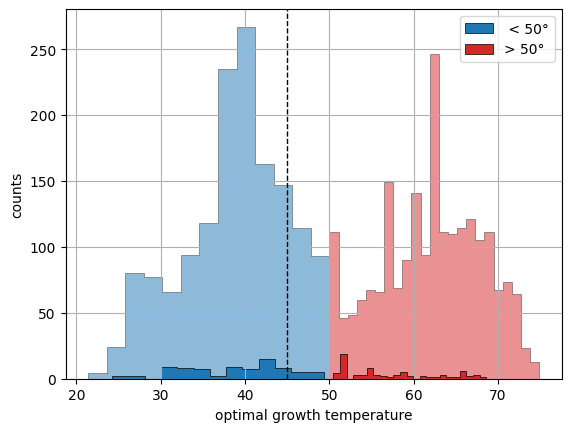

num low = 1482; num high = 2099;


In [9]:
#plt.figure(figsize=(5, 3))

plt.hist(y_low, bins=13, alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:blue')
plt.hist(y_test_low, bins=13, label = " < 50°", alpha = 1, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:blue')
plt.hist(y_high, bins=23, alpha = 0.5, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:red')
plt.hist(y_test_high, bins=23, label = "> 50°", alpha = 1, histtype='stepfilled', edgecolor='black', linewidth=0.5, color='tab:red')
plt.axvline(45, color='black', linestyle='--', linewidth=1)

plt.grid(True)

plt.xlabel("optimal growth temperature")
plt.ylabel("counts")
plt.grid(True)
plt.legend();

plt.savefig(f"{OUTPUT_DIRECTORY}/two_sample_classes.pdf", format="pdf")
plt.show()

print(f"num low = {len(y_low)}; num high = {len(y_high)};")

Shape of the projected data = (3734, 2)


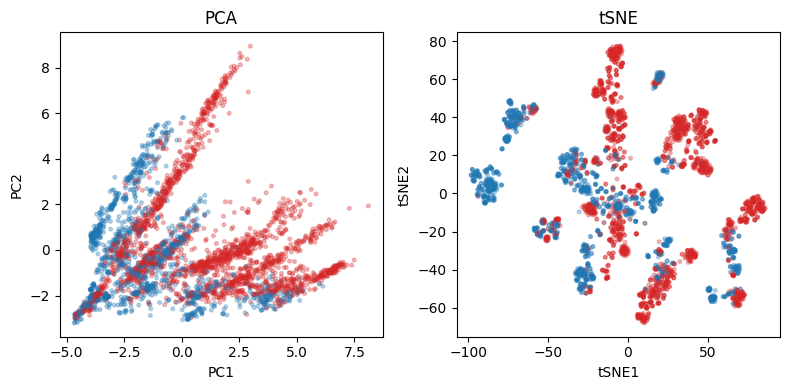

In [18]:
from utils.utils import pca_run_and_plot, tsne_plot
from matplotlib.colors import ListedColormap

y_train_masked = [1 if yi > low_q else 0 for yi in y_label.cpu()]

colors = ListedColormap(["tab:blue", "tab:red"])

plt.figure(figsize=(8, 4))
colorbar = False

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 10
pca_run_and_plot(X_val.cpu(), n_compon, y_train_masked, None, colors, False, colorbar, alpha=0.3, s = 7);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, y_train_masked, colors, colorbar, alpha=0.3, s = 7);

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_two_temp_ranges.pdf", format="pdf")
plt.show()

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error


# --- 1. Label each sample as low, mid, or high OGT group
def label_ogt_range(y,high_thresh=50):
    labels = []
    for val in y:
        if val < high_thresh:
            labels.append('low')
        else:
            labels.append('high')
    return np.array(labels)

# Assign labels
range_labels = label_ogt_range(y_train)

le = LabelEncoder()
range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2

label_to_int = {'low': 0, 'high': 1}

# Vectorized conversion
range_ids = np.vectorize(label_to_int.get)(range_labels)

range_labels_test = label_ogt_range(y_test)
range_ids_test = np.vectorize(label_to_int.get)(range_labels_test)

(array([574., 592.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

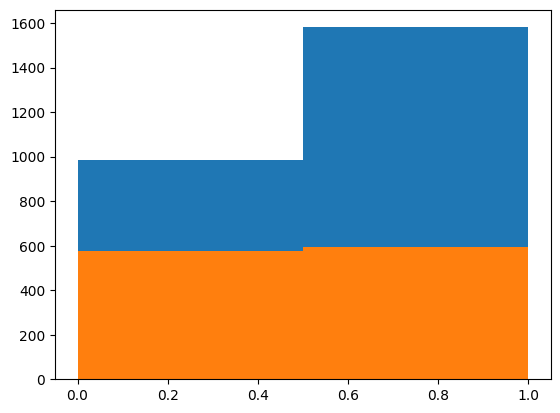

In [10]:
plt.hist(range_ids, bins=2)
plt.hist(range_ids_test, bins=2)

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(range_ids)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)

# Convert to dictionary format for xgboost
class_weights = dict(zip(classes, weights))

# class_weights[0]=1
# class_weights[1]=10

# Pass weights to each sample
sample_weights = np.array([class_weights[c] for c in range_ids])

class_weights

{np.int64(0): np.float64(1.3009118541033435),
 np.int64(1): np.float64(0.8121442125237192)}

In [12]:
def xgboost_mixture_of_experts_2_class(X_train, y_train, range_ids, sample_weights, X_test):

    num_classes = 2
    temp_bound = 45
    gating_model = XGBClassifier(
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",   # Binary classification objective
        eval_metric="logloss",         # Suitable for binary classification
    )

    gating_model.fit(X_train.cpu(), range_ids,sample_weight=sample_weights )  # Predicts soft assignments to experts

    # --- 4. Get gating probabilities (soft weights for each expert)
    gate_probs = gating_model.predict_proba(X_test.cpu())  # Shape: (n_samples, 3)
    gate_preds = gating_model.predict(X_test.cpu()) 

    y_train = y_train.squeeze()

    # Define masks (all 1D)
    low_mask  = y_train < temp_bound
    high_mask = y_train >= temp_bound

    # Apply masks correctly
    X_low, y_low   = X_train[low_mask].cpu(), y_train[low_mask].cpu()
    X_high, y_high = X_train[high_mask].cpu(), y_train[high_mask].cpu()

    model_low  = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05).fit(X_low, y_low)
    model_high =  XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05).fit(X_high, y_high)

    pred_low  = model_low.predict(X_test)
    pred_high = model_high.predict(X_test)

    final_pred = (
        gate_probs[:, 0]  * pred_low +
        gate_probs[:, 1] * pred_high
    )

    return gating_model, gate_probs, final_pred

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.model_selection import KFold, GroupKFold
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
import subprocess

def is_gpu_available():
    try:
        subprocess.check_output(["nvidia-smi"])
        return True
    except Exception:
        return False

def xgboost_mixture_of_experts_2_class_cv_full(X_train, y_train, range_ids, sample_weights, X_test, y_test, n_splits=5, taxonomy_labels=None):
    num_classes = 2
    temp_bound = 50
   # kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Choose fold strategy
    if taxonomy_labels is not None:
        fold_generator = GroupKFold(n_splits=n_splits).split(X_train, y_train, groups=taxonomy_labels)
    else:
        fold_generator = KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_train, y_train)

    # Device-aware XGBoost config
    if is_gpu_available():
        tree_method = "hist"
        device = "cuda"
       # print("GPU detected: using CUDA device.")
    else:
        tree_method = "hist"
        device = "cpu"
      #  print("No GPU: using CPU.")


    # Convert to numpy
    X_train_np = X_train.cpu().numpy()
    y_train_np = y_train.cpu().numpy().flatten()
    X_test_np = X_test.cpu().numpy()
    y_test_np = y_test.cpu().numpy().flatten()
    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    final_cv_preds = np.zeros_like(y_train_np, dtype=float)
    true_cv_vals = np.zeros_like(y_train_np, dtype=float)
    gate_probs_cv = np.zeros((len(y_train_np), num_classes))

    gate_true_cv = np.zeros_like(y_train_np, dtype=int)
    gate_preds_cv = np.zeros_like(y_train_np, dtype=int)

    mcc_scorer = make_scorer(matthews_corrcoef)

    for train_index, val_index in fold_generator:#kf.split(X_train_np):
        X_tr, X_val = X_train_np[train_index], X_train_np[val_index]
        y_tr, y_val = y_train_np[train_index], y_train_np[val_index]
        w_tr = sample_weights_np[train_index]
        r_tr = range_ids_np[train_index]

        gating_model = XGBClassifier(
            n_jobs=-1,
            tree_method=tree_method,
            device=device,
            #predictor=predictor,
            objective="binary:logistic",
            eval_metric="logloss"
        )
        gating_model.fit(X_tr, r_tr, sample_weight=w_tr)
        gate_probs_val = gating_model.predict_proba(X_val)
        gate_preds_val = np.argmax(gate_probs_val, axis=1)

        gate_true_val = (y_val >= temp_bound).astype(int)
        gate_preds_cv[val_index] = gate_preds_val
        gate_true_cv[val_index] = gate_true_val

        # Expert models
        low_mask = y_tr < temp_bound
        high_mask = y_tr >= temp_bound

        model_low = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                 tree_method=tree_method, device=device)
        model_high = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                  tree_method=tree_method, device=device)

        model_low.fit(X_tr[low_mask], y_tr[low_mask])
        model_high.fit(X_tr[high_mask], y_tr[high_mask])

        pred_low = model_low.predict(X_val)
        pred_high = model_high.predict(X_val)

        final_val_pred = gate_probs_val[:, 0] * pred_low + gate_probs_val[:, 1] * pred_high

        final_cv_preds[val_index] = final_val_pred
        true_cv_vals[val_index] = y_val
        gate_probs_cv[val_index] = gate_probs_val

    cv_metrics = {
        "accuracy": accuracy_score(gate_true_cv, gate_preds_cv),
        'balanced_accuracy': balanced_accuracy_score(gate_true_cv, gate_preds_cv),
        "precision": precision_score(gate_true_cv, gate_preds_cv),
        "recall": recall_score(gate_true_cv, gate_preds_cv),
        "f1": f1_score(gate_true_cv, gate_preds_cv),
        'mcc': matthews_corrcoef(gate_true_cv, gate_preds_cv),
    }

    # Final models on full training
    gating_model_full = XGBClassifier(
        n_jobs=-1,
        tree_method=tree_method,
        device=device,
        objective="binary:logistic",
        eval_metric="logloss"
    )
    gating_model_full.fit(X_train_np, range_ids_np, sample_weight=sample_weights_np)
    gate_probs_test = gating_model_full.predict_proba(X_test_np)
    gate_preds_test = np.argmax(gate_probs_test, axis=1)
    gate_true_test = (y_test_np >= temp_bound).astype(int)

    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    model_low = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                             tree_method=tree_method, device=device)
    model_high = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                              tree_method=tree_method, device=device)

    model_low.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high.fit(X_train_np[high_mask], y_train_np[high_mask])

    pred_low = model_low.predict(X_test_np)
    pred_high = model_high.predict(X_test_np)
    final_test_pred = gate_probs_test[:, 0] * pred_low + gate_probs_test[:, 1] * pred_high

    test_metrics = {
        "accuracy": accuracy_score(gate_true_test, gate_preds_test),
        "balanced_accuracy": balanced_accuracy_score(gate_true_test, gate_preds_test),
        "precision": precision_score(gate_true_test, gate_preds_test),
        "recall": recall_score(gate_true_test, gate_preds_test),
        "f1": f1_score(gate_true_test, gate_preds_test),
        'mcc': matthews_corrcoef(gate_true_test, gate_preds_test),
    }

    return {
        "cv_predictions": final_cv_preds,
        "cv_true": true_cv_vals,
        "cv_gate_probs": gate_probs_cv,
        "test_predictions": final_test_pred,
        "gating_model": gating_model_full,
        "gate_probs_test": gate_probs_test,
        "cv_metrics": cv_metrics,
        "test_metrics": test_metrics
    }


In [14]:
gating_model, gate_probs, final_pred = xgboost_mixture_of_experts_2_class(X_train.cpu(), y_train.cpu(), range_ids, sample_weights, X_test.cpu())

In [22]:
taxa_group_names_train

In [23]:
dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_train, y_train, range_ids, sample_weights, X_test, y_test, taxonomy_labels=taxa_group_names_train)
dict_res_two_class["cv_metrics"]

{'accuracy': 0.9176207763194638,
 'precision': 0.8914930555555556,
 'recall': 0.9785612196283945,
 'f1': 0.9330002271178742}

In [24]:
dict_res_two_class["test_metrics"]

{'accuracy': 0.49019607843137253,
 'precision': 0.4846153846153846,
 'recall': 0.8513513513513513,
 'f1': 0.6176470588235294}

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

gate_preds = gating_model.predict(X_test.cpu()) 

print(classification_report(range_ids_test,gate_preds))

# Confusion matrix
cm = confusion_matrix(range_ids_test, gate_preds)

sns.heatmap(cm, annot=True, xticklabels=["low", "high"], yticklabels=["low", "high"], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Gating Model Confusion Matrix")
plt.show()

NameError: name 'gating_model' is not defined

In [14]:
from utils.utils import train_xgboost, calculate_aver_std
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


plt.figure(figsize=(10, 8))

y_test = y_test.cpu()
mx_prob = [max(g) for g in gate_probs]
mx_prob_cv = [max(g) for g in dict_res_two_class["cv_gate_probs"]]

num_bins = 20
min_temp = min(y_test.squeeze())
max_temp = max(y_test.squeeze())

# Cross-Validation: prediction vs actual
plt.subplot(2, 2, 1) 
plt.scatter(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"], marker='o', alpha = 0.7,c = mx_prob_cv, s=7)
bin_centers, mean_diff, std_diff = calculate_aver_std(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"], num_bins)
rmse_cv = np.sqrt(mean_squared_error(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"]))
r2_cv = r2_score(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"])
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:purple', capsize=3, label='mixture model mean ± std')
plt.errorbar(bin_centers_cv_old, mean_diff_cv_old, yerr=std_diff_cv_old, fmt='o-', color='tab:red', capsize=3, label='global model mean ± std')
plt.plot([min_temp,max_temp],[min_temp,max_temp], c = "black", linestyle='--', linewidth=2.5) 
plt.xlabel("true OGT")
plt.ylabel("predicted OGT")
plt.title(f"CV | RMSE = {rmse_cv:.2f} | R² = {r2_cv:.2f}")
plt.legend()
plt.grid(True)
cbar = plt.colorbar()

# Diff for full signal  
plt.subplot(2, 2, 2) 
y_test = y_test.cpu()
diff =  dict_res_two_class["cv_predictions"] - dict_res_two_class["cv_true"]#[dict_res["cv_predictions"] - dict_res["cv_true"] for i in range(len(dict_res["cv_predictions"]))]
bin_centers, mean_diff, std_diff = calculate_aver_std(dict_res_two_class["cv_true"], np.array([x.item() for x in diff]), num_bins)
plt.scatter(dict_res_two_class["cv_true"], diff, marker='o', alpha = 1, c = mx_prob_cv, s=7, facecolor='none')    
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:purple', capsize=3, label='mixture model mean ± std')
plt.errorbar(bin_centers_test_old, mean_diff_test_old, yerr=std_diff_test_old, fmt='o-', color='tab:red', capsize=3, label='global model mean ± std')
plt.plot([min_temp,max_temp],[0,0], c = "black", linestyle='--', linewidth=2.5) 
plt.xlabel("true OGT")
plt.ylabel("(predicted - true) OGT")
plt.title(f"Discrepancy | test aver = {mean_test:.2f}")
plt.legend()
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label("classifier confidence", rotation=90, labelpad=15)  # vertical title


# Cross-Validation: prediction vs actual
plt.subplot(2, 2, 3) 
plt.scatter(y_test.cpu(), final_pred, marker='o', alpha = 1, c = mx_prob, s=7)
bin_centers, mean_diff, std_diff = calculate_aver_std(y_test.squeeze(), final_pred, num_bins)
rmse_test = np.sqrt(mean_squared_error(y_test.squeeze(), final_pred))
r2_test = r2_score(y_test.squeeze(), final_pred)
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:purple', capsize=3, label='mixture model mean ± std')
plt.plot([min_temp,max_temp],[min_temp,max_temp], c = "black", linestyle='--', linewidth=2.5) 
plt.xlabel("true OGT")
plt.ylabel("predicted OGT")
plt.title(f"Test | RMSE = {rmse_test:.2f} | R² = {r2_test:.2f}")

plt.errorbar(bin_centers_cv_old, mean_diff_cv_old, yerr=std_diff_cv_old, fmt='o-', color='tab:red', capsize=3, label='global model mean ± std')
plt.legend()
plt.grid(True)
cbar = plt.colorbar()

# Diff for full signal  
plt.subplot(2, 2, 4) 
y_test = y_test.cpu()
diff = [final_pred[i] - y_test[i] for i in range(len(final_pred))]
bin_centers, mean_diff, std_diff = calculate_aver_std(y_test.squeeze(), np.array([x.item() for x in diff]), num_bins)
plt.scatter(y_test.cpu(), diff, marker='o', alpha = 1, c = mx_prob, s=7, facecolor='none')    
plt.errorbar(bin_centers, mean_diff, yerr=std_diff, fmt='o-', color='tab:purple', capsize=3, label='mixture model  mean ± std')
plt.plot([min_temp,max_temp],[0,0], c = "black", linestyle='--', linewidth=2.5) 

plt.errorbar(bin_centers_test_old, mean_diff_test_old, yerr=std_diff_test_old, fmt='o-', color='tab:red', capsize=3, label='global model mean ± std')

plt.xlabel("true OGT")
plt.ylabel("(predicted - true) OGT")
plt.title(f"Discrepancy | test aver = {mean_test:.2f}")
plt.legend()
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label("classifier confidence", rotation=90, labelpad=15)  # vertical title




# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/mixture_of_experts_2_class.pdf", format="pdf")
plt.show()

NameError: name 'gate_probs' is not defined

<Figure size 1000x800 with 0 Axes>

In [107]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
# Suppress the UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [108]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from sklearn.utils.class_weight import compute_class_weight

In [109]:
max_accur_split = -10
max_accur_split_id = None

In [110]:
cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)

test_accur_dict_splits_baseline = defaultdict(list)

for split_id in all_splits_dict.keys():
    print(f"split = {split_id}")
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]
    X_val_test = all_splits_dict[split_id]["X_test"]
    y_label_test = all_splits_dict[split_id]["y_test"]

    taxa_group_names_train =  all_splits_dict[split_id]["taxa_group_names_train"]

    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    #class_weights[0]=1
   # class_weights[1]=10
    sample_weights = np.array([class_weights[c] for c in range_ids])


    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_val_train, y_label_train, range_ids, sample_weights, X_val_test, y_label_test, taxonomy_labels=taxa_group_names_train)
        if dict_res_two_class["test_metrics"]['mcc'] > max_accur_split:
            max_accur_split = dict_res_two_class["test_metrics"]['mcc']
            max_accur_split_id = split_id
   # cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE)
    for accur_measure in dict_res_two_class["cv_metrics"].keys():
        cv_accur_dict_splits[accur_measure].append(dict_res_two_class["cv_metrics"][accur_measure])
        test_accur_dict_splits[accur_measure].append(dict_res_two_class["test_metrics"][accur_measure])

    temp_bound = 50
    y_label_test_bin  = (y_label_test.squeeze() > temp_bound).long().cpu().numpy()

    #Calculate the baseline accuracies
    N_tot = len(y_label_test_bin)
    N_1 = sum(y_label_test_bin).item()
    N_0 = N_tot - N_1
    fp = tn = N_0/2
    tp = fn = N_1/2

    if tp+fn >0:
        pres = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*(pres*recall)/(pres+recall)
        mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    
        test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
        test_accur_dict_splits_baseline["balanced_accuracy"].append(0.5)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["mcc"].append(mcc)
        
    mean_val = y_label_test.mean().cpu()
    mean_tensor = torch.full_like(y_label_test, mean_val)
    rmse_baseline = np.sqrt(mean_squared_error(mean_tensor.cpu(), y_label_test.cpu()))

    test_accur_dict_splits_baseline["r2"].append(0)
    test_accur_dict_splits_baseline["rmse"].append(rmse_baseline)

    
    y_true = dict_res_two_class["cv_true"]
    y_pred = dict_res_two_class["cv_predictions"]
    
    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    cv_accur_dict_splits["rmse"].append(rmse_cv)
    r2_cv = r2_score(y_true, y_pred)
    cv_accur_dict_splits["r2"].append(r2_cv)

    # Boolean masks
    mask_high = (y_true > temp_bound).squeeze()
    mask_low = (y_true < temp_bound).squeeze()

   # print(f"y_true[mask_high] = {y_true[mask_high]}")
   # print(f"y_pred[mask_high] = {y_pred[mask_high]}")
    
    # Compute metrics for y_true > temp_bound
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high])
    cv_accur_dict_splits["rmse_high"].append(rmse_high)
    cv_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < temp_bound
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    cv_accur_dict_splits["rmse_low"].append(rmse_low)
    cv_accur_dict_splits["r2_low"].append(r2_low)


    y_true = y_label_test.cpu()
    y_pred = dict_res_two_class["test_predictions"]
    
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    test_accur_dict_splits["rmse"].append(rmse_test)
    r2_test = r2_score(y_true, y_pred)
    test_accur_dict_splits["r2"].append(r2_test)

    # Boolean masks
    mask_high = (y_true > temp_bound).squeeze()
    mask_low = (y_true < temp_bound).squeeze()
    
    # Compute metrics for y_true > temp_bound
    rmse_high = np.sqrt(mean_squared_error(y_true[mask_high], y_pred[mask_high.squeeze()]))
    r2_high = r2_score(y_true[mask_high], y_pred[mask_high.squeeze()])
    test_accur_dict_splits["rmse_high"].append(rmse_high)
    test_accur_dict_splits["r2_high"].append(r2_high)
    
    # Compute metrics for y_true < temp_bound
    rmse_low = np.sqrt(mean_squared_error(y_true[mask_low], y_pred[mask_low]))
    r2_low = r2_score(y_true[mask_low], y_pred[mask_low])
    test_accur_dict_splits["rmse_low"].append(rmse_low)
    test_accur_dict_splits["r2_low"].append(r2_low)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in cv_accur_dict_splits.keys():
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])
    test_accur_dict_splits_baseline_mean[accur_measure] = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure] = np.std(test_accur_dict_splits_baseline[accur_measure])

split = 0


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_cor

In [111]:
print(max_accur_split)
print(max_accur_split_id)


0.1379959041029793
0


In [112]:
print(cv_accur_dict_mean)
print(cv_accur_dict_std)
print(test_accur_dict_mean)
print(test_accur_dict_std)

defaultdict(<class 'float'>, {'accuracy': np.float64(0.9511309690030718), 'balanced_accuracy': np.float64(0.9507763159502083), 'precision': np.float64(0.9633911368015414), 'recall': np.float64(0.9528346831824679), 'f1': np.float64(0.9580838323353293), 'mcc': np.float64(0.8995793594032888), 'rmse': np.float64(3.808290544754824), 'r2': np.float64(0.9134173010303422), 'rmse_high': np.float64(3.806598355715728), 'r2_high': np.float64(0.5927221285073035), 'rmse_low': np.float64(3.8071321194474232), 'r2_low': np.float64(0.614851090190605)})
defaultdict(<class 'float'>, {'accuracy': np.float64(0.0), 'balanced_accuracy': np.float64(0.0), 'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0), 'mcc': np.float64(0.0), 'rmse': np.float64(0.0), 'r2': np.float64(0.0), 'rmse_high': np.float64(0.0), 'r2_high': np.float64(0.0), 'rmse_low': np.float64(0.0), 'r2_low': np.float64(0.0)})
defaultdict(<class 'float'>, {'accuracy': np.float64(0.5686274509803921), 'balanced_accuracy': 

In [113]:
cv_accur_dict_mean.keys()

metrics = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std, "test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'rmse_low', 'r2_low', 'rmse_high', 'r2_high', 'rmse', 'r2'])
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics.csv")

print(df)

                    cv mean  cv std  test mean  test std  test baseline mean  \
balanced_accuracy  0.950776     0.0   0.569022       0.0            0.500000   
accuracy           0.951131     0.0   0.568627       0.0            0.500000   
precision          0.963391     0.0   0.551282       0.0            0.483660   
recall             0.952835     0.0   0.581081       0.0            0.500000   
f1                 0.958084     0.0   0.565789       0.0            0.491694   
mcc                0.899579     0.0   0.137996       0.0            0.000000   
rmse_low           3.807132     0.0  12.407178       0.0                 NaN   
r2_low             0.614851     0.0  -3.229735       0.0                 NaN   
rmse_high          3.806598     0.0   9.138095       0.0                 NaN   
r2_high            0.592722     0.0  -1.678558       0.0                 NaN   
rmse               3.808291     0.0  10.948621       0.0           10.831813   
r2                 0.913417     0.0  -0.

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get feature importances from trained model
importances = gating_model.feature_importances_

# Use your actual column names
feature_names = X_column_names  # Make sure it's a list of strings

# Pair and sort
feature_importance_list = sorted(zip(feature_names, importances), key=lambda x: -x[1])

# Print top features
print("Top 20 important features:")
for feature, score in feature_importance_list[:20]:
    print(f"{feature}: {score:.4f}")

booster = gating_model.get_booster()

# Assign actual feature names
booster.feature_names = list(X_column_names)

# Plot
xgb.plot_importance(gating_model, max_num_features=20, importance_type='gain')
plt.title("Top 20 Important Features (Gain)")
plt.tight_layout()
plt.show()



Average counts for top 20 features by class:
        COG0349   COG4123   COG1643   COG0692   COG1391   COG1192   COG4735  \
label                                                                         
0      0.127885  0.917308  0.064423  0.798077  0.015385  1.736538  0.163462   
1      0.659014  0.340986  0.952381  0.676020  0.515306  2.581633  0.039116   

        COG1577   COG2384   COG0312   COG3824   COG0280   COG4747   COG0712  \
label                                                                         
0      0.882692  0.499038  0.642308  0.020192  1.150000  0.130769  0.875000   
1      0.261054  0.133503  0.968537  0.772959  0.708333  0.324830  0.763605   

        COG4094   COG0699   COG3360   COG0266   COG2870   COG4636  
label                                                              
0      0.028846  0.905769  0.079808  0.632692  0.093269  2.161538  
1      0.014456  1.170918  0.364796  1.870748  0.228741  2.607143  


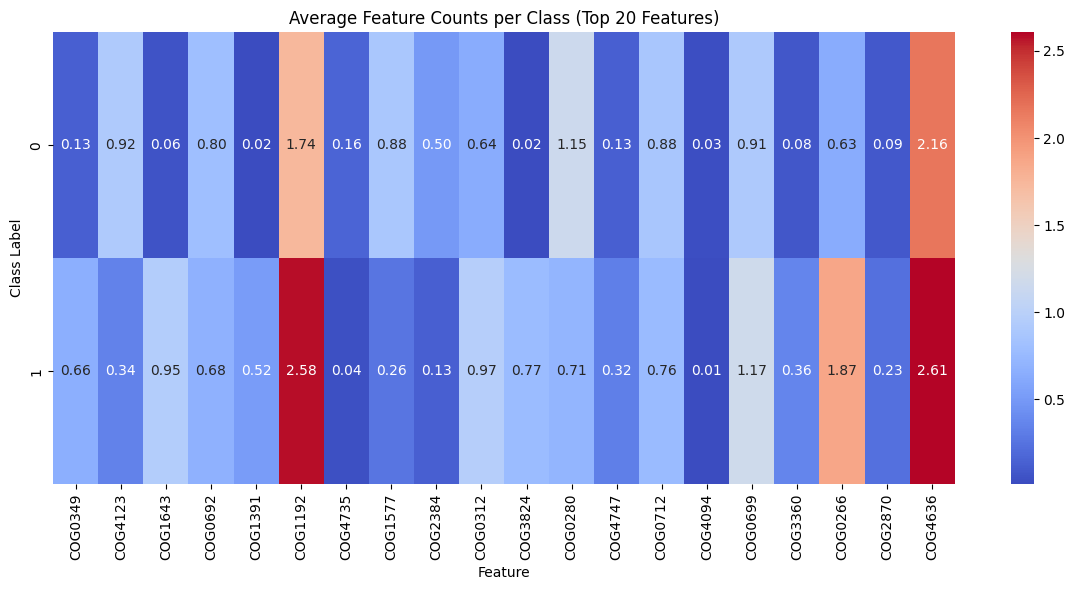

In [142]:
import numpy as np
import pandas as pd

# Convert to DataFrame for easier handling
df = pd.DataFrame(X_train.cpu(), columns=X_column_names)
df['label'] = range_ids

# Top 20 important features
top_features = [f for f, _ in feature_importance_list[:20]]

# Compute average counts for each class
grouped_means = df.groupby('label')[top_features].mean()

# Print results
print("\nAverage counts for top 20 features by class:")
print(grouped_means)

# Optional: visualize as heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(grouped_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Average Feature Counts per Class (Top 20 Features)")
plt.xlabel("Feature")
plt.ylabel("Class Label")
plt.tight_layout()
plt.show()


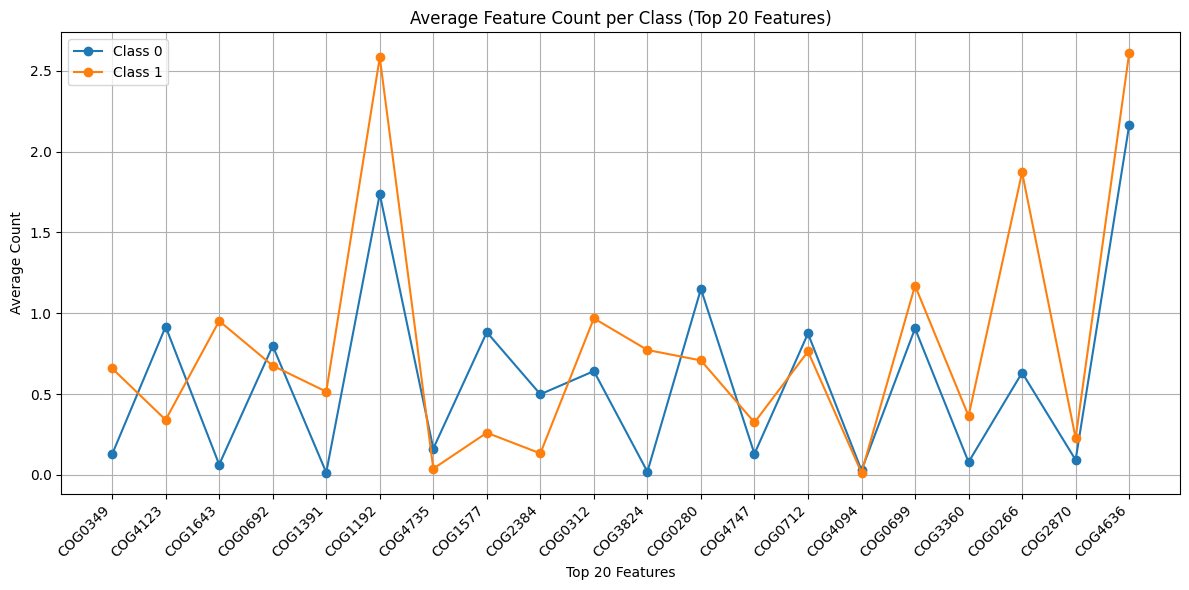

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame if not already
df = pd.DataFrame(X_train.cpu(), columns=X_column_names)
df['label'] = range_ids

# Get top 20 important features
top_features = [f for f, _ in feature_importance_list[:20]]

# Compute mean feature values per class
grouped_means = df.groupby('label')[top_features].mean()

# Plot lines for each class
plt.figure(figsize=(12, 6))

for class_label in grouped_means.index:
    plt.plot(top_features, grouped_means.loc[class_label], marker='o', label=f'Class {class_label}')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Top 20 Features")
plt.ylabel("Average Count")
plt.title("Average Feature Count per Class (Top 20 Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


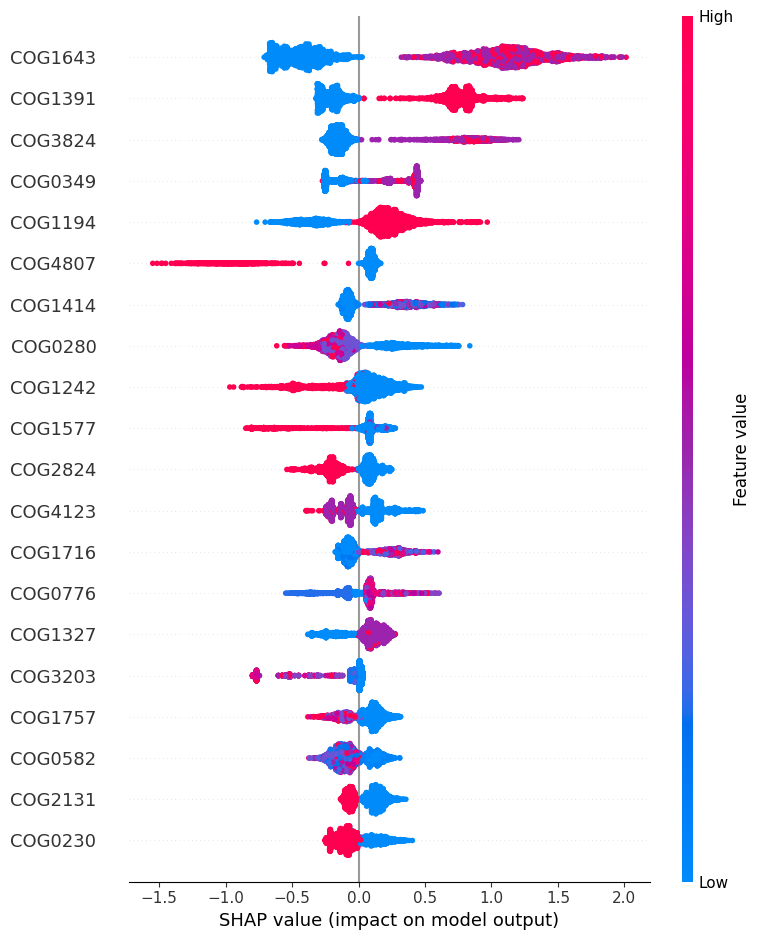

In [144]:
import pandas as pd
import shap

X_train = X_train.cpu()

# If X_train is a NumPy array, convert it:
X_train_df = pd.DataFrame(X_val.cpu(), columns=X_column_names)

# Recompute SHAP values if needed
explainer = shap.TreeExplainer(gating_model)
shap_values = explainer.shap_values(X_train_df)

# If it's a binary classifier:
shap.summary_plot(shap_values, X_train_df)


(array([ 10.,  84., 313., 462., 651., 757., 785., 501., 153.,  18.]),
 array([17.46551323, 17.87119675, 18.27688026, 18.68256378, 19.0882473 ,
        19.49393082, 19.89961624, 20.30529976, 20.71098328, 21.11666679,
        21.52235031]),
 <BarContainer object of 10 artists>)

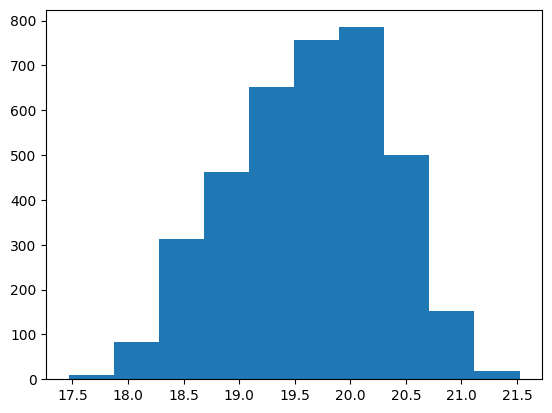

In [145]:
shap_sum_per_sample = np.abs(shap_values).sum(axis=1)
plt.hist(shap_sum_per_sample)

Shape of the projected data = (3734, 2)


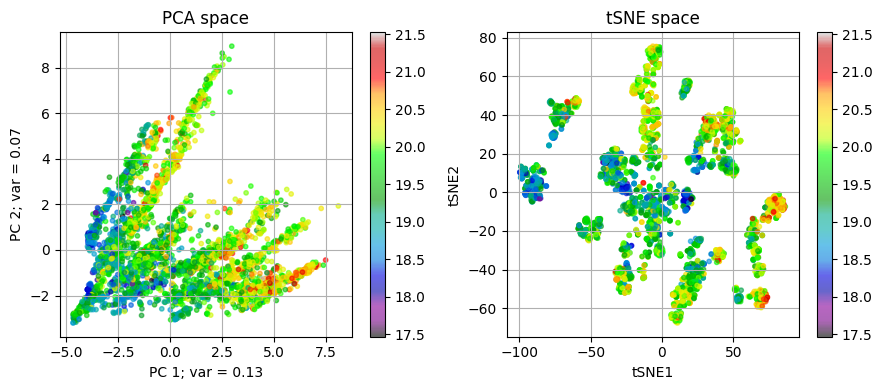

In [146]:
from utils.utils import pca_run_and_plot, tsne_plot

plt.figure(figsize=(9, 4))
X_train, y_train, X_test, y_test = X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu()
colorbar = True

# PCA space
plt.subplot(1, 2, 1) 
n_compon = 10
pca_run_and_plot(X_val.cpu(), n_compon, shap_sum_per_sample, None, None, False, colorbar);

# t-SNE space
plt.subplot(1, 2, 2) 
tsne_plot(X_val.cpu(), 50, 100, RANDOM_SEED, shap_sum_per_sample, None, colorbar);


# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_shap_sum.pdf", format="pdf")
plt.show()

# Feature selection

In [114]:
from tqdm import tqdm


def xgboost_accuracy_multi_expert(X_train, X_test, y_train, y_test, sorted_cog_idx, feat_step, feat_removal = False, groups=None):
    rmse_test_arr = []
    r2_test_arr = []
    rmse_cv_arr = []
    r2_cv_arr = []

    gating_balanced_accur_cv_arr = []
    gating_accur_cv_arr = []
    gating_precision_cv_arr = []
    gating_recall_cv_arr = []
    gating_f1_cv_arr = []
    gating_mcc_cv_arr = []
    
    gating_balanced_accur_test_arr = []
    gating_accur_test_arr = []
    gating_precisio_test_arr = []
    gating_recall_test_arr = []
    gating_f1_test_arr = []
    gating_mcc_test_arr = []
    
    num_feat = range(1,len(sorted_cog_idx),feat_step)
    num_feat_plot = []
  #  for N in tqdm(num_feat, desc="Running mixture of experts..."):
    for N in num_feat:
        if feat_removal == False:
            select_feat = list(sorted_cog_idx[:N])
        else:
            select_feat = list(sorted_cog_idx[N:])
        num_feat_plot.append(N)#len(select_feat))    
        X_train_select_feat = X_train[:, select_feat]
        X_test_select_feat = X_test[:, select_feat]

        dict_res_two_class = xgboost_mixture_of_experts_2_class_cv_full(X_train_select_feat, y_train, range_ids, sample_weights, X_test_select_feat, y_test, taxonomy_labels=groups)

        rmse_test = np.sqrt(mean_squared_error(y_test, dict_res_two_class["test_predictions"]))
        rmse_test_arr.append(rmse_test)
        r2_test = r2_score(y_test, dict_res_two_class["test_predictions"])
        r2_test_arr.append(r2_test)
        
        rmse_cv = np.sqrt(mean_squared_error(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"]))
        rmse_cv_arr.append(rmse_cv)
        r2_cv = r2_score(dict_res_two_class["cv_true"], dict_res_two_class["cv_predictions"])
        r2_cv_arr.append(r2_cv)
        
        gating_accur_cv_arr.append(dict_res_two_class["cv_metrics"]["accuracy"])  
        gating_balanced_accur_cv_arr.append(dict_res_two_class["cv_metrics"]["balanced_accuracy"])  
        gating_precision_cv_arr.append(dict_res_two_class["cv_metrics"]["precision"])
        gating_recall_cv_arr.append(dict_res_two_class["cv_metrics"]["recall"])
        gating_f1_cv_arr.append(dict_res_two_class["cv_metrics"]["f1"])
        gating_mcc_cv_arr.append(dict_res_two_class["cv_metrics"]["mcc"])

        gating_balanced_accur_test_arr.append(dict_res_two_class["test_metrics"]["balanced_accuracy"])
        gating_accur_test_arr.append(dict_res_two_class["test_metrics"]["accuracy"])
        gating_precisio_test_arr.append(dict_res_two_class["test_metrics"]["precision"])
        gating_recall_test_arr.append(dict_res_two_class["test_metrics"]["recall"])
        gating_f1_test_arr.append(dict_res_two_class["test_metrics"]["f1"])
        gating_mcc_test_arr.append(dict_res_two_class["test_metrics"]["mcc"])

    gating_cv_metrics = {
        "balanced_accuracy_arr": gating_balanced_accur_cv_arr,
        "accuracy_arr": gating_accur_cv_arr,
        "precision_arr": gating_precision_cv_arr,
        "recall_arr": gating_recall_cv_arr,
        "f1_arr": gating_f1_cv_arr,
        "mcc_arr": gating_mcc_cv_arr
    }

    gating_test_metrics = {
        "balanced_accuracy_arr": gating_balanced_accur_test_arr,
        "accuracy_arr": gating_accur_test_arr,
        "precision_arr": gating_precisio_test_arr,
        "recall_arr": gating_recall_test_arr,
        "f1_arr": gating_f1_test_arr,
        "mcc_arr": gating_mcc_test_arr
    }
    
    return rmse_test_arr, r2_test_arr, rmse_cv_arr, r2_cv_arr, num_feat_plot, gating_cv_metrics, gating_test_metrics

In [115]:
def random_feat_removal_curves_ogt(X_train, X_test, y_train, y_test, num_runs, feat_step, feat_removal, taxa_group_names_train):
    tot_num_feat = X_train.cpu().shape[1]
    rmse_test_arr_mi_tot = []
    r2_test_arr_mi_tot = []
    rmse_cv_arr_mi_tot = []
    r2_cv_arr_mi_tot = []

    gating_accur_cv_tot = []
    gating_balanced_accur_cv_tot = []
    gating_preci_cv_tot = []
    gating_recall_cv_tot = []
    gating_f1_cv_tot = []
    gating_mcc_cv_tot = []

    gating_accur_test_tot = []
    gating_balanced_accur_test_tot = []
    gating_preci_test_tot = []
    gating_recall_test_tot = []
    gating_f1_test_tot = []
    gating_mcc_test_tot = []
    
    range_labels = label_ogt_range(y_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    for i in range(num_runs):
        print(f"Processing random feature combo {i}")
        shuffled_indices = np.random.permutation(tot_num_feat)

        rmse_test_arr_mi, r2_test_arr_mi, rmse_cv_arr_mi, r2_cv_arr_mi, num_feat_plot, gating_cv_metrics, gating_test_metrics = xgboost_accuracy_multi_expert(X_train.cpu(), X_test.cpu(), y_train, y_test, shuffled_indices, feat_step, feat_removal, taxa_group_names_train)
        rmse_test_arr_mi_tot.append(rmse_test_arr_mi)
        r2_test_arr_mi_tot.append(r2_test_arr_mi)
        rmse_cv_arr_mi_tot.append(rmse_cv_arr_mi)
        r2_cv_arr_mi_tot.append(r2_cv_arr_mi)

        gating_accur_cv_tot.append(gating_cv_metrics["accuracy_arr"])
        gating_balanced_accur_cv_tot.append(gating_cv_metrics["balanced_accuracy_arr"])
        gating_preci_cv_tot.append(gating_cv_metrics["precision_arr"])
        gating_recall_cv_tot.append(gating_cv_metrics["recall_arr"])
        gating_f1_cv_tot.append(gating_cv_metrics["f1_arr"])
        gating_mcc_cv_tot.append(gating_cv_metrics["mcc_arr"])
        
        gating_accur_test_tot.append(gating_test_metrics["accuracy_arr"])
        gating_balanced_accur_test_tot.append(gating_test_metrics["balanced_accuracy_arr"])
        gating_preci_test_tot.append(gating_test_metrics["precision_arr"])
        gating_recall_test_tot.append(gating_test_metrics["recall_arr"])
        gating_f1_test_tot.append(gating_test_metrics["f1_arr"])
        gating_mcc_test_tot.append(gating_test_metrics["mcc_arr"])
        
    rmse_test_arr_mi_mean = np.array(rmse_test_arr_mi_tot).mean(axis=0)  
    rmse_test_arr_mi_std = np.array(rmse_test_arr_mi_tot).std(axis=0)  
    
    r2_test_arr_mi_mean = np.array(r2_test_arr_mi_tot).mean(axis=0)  
    r2_test_arr_mi_std = np.array(r2_test_arr_mi_tot).std(axis=0)  
    
    rmse_cv_arr_mi_mean = np.array(rmse_cv_arr_mi_tot).mean(axis=0)  
    rmse_cv_arr_mi_std = np.array(rmse_cv_arr_mi_tot).std(axis=0)  
    
    r2_cv_arr_mi_mean = np.array(r2_cv_arr_mi_tot).mean(axis=0)  
    r2_cv_arr_mi_std = np.array(r2_cv_arr_mi_tot).std(axis=0)  

    rmse_test_curve = {"mean": rmse_test_arr_mi_mean, "std": rmse_test_arr_mi_std}
    r2_test_curve = {"mean": r2_test_arr_mi_mean, "std": r2_test_arr_mi_std}
    rmse_cv_curve = {"mean": rmse_cv_arr_mi_mean, "std": rmse_cv_arr_mi_std}
    r2_cv_curve = {"mean": r2_cv_arr_mi_mean, "std": r2_cv_arr_mi_std}


    gating_balanced_accur_cv_mean = np.array(gating_balanced_accur_cv_tot).mean(axis=0)  
    gating_balanced_accur_cv_std = np.array(gating_balanced_accur_cv_tot).std(axis=0) 
    gating_balanced_accur_cv_curve = {"mean": gating_balanced_accur_cv_mean, "std": gating_balanced_accur_cv_std}

    gating_accur_cv_mean = np.array(gating_accur_cv_tot).mean(axis=0)  
    gating_accur_cv_std = np.array(gating_accur_cv_tot).std(axis=0) 
    gating_accur_cv_curve = {"mean": gating_accur_cv_mean, "std": gating_accur_cv_std}
    
    gating_preci_cv_mean = np.array(gating_preci_cv_tot).mean(axis=0)  
    gating_preci_cv_std = np.array(gating_preci_cv_tot).std(axis=0) 
    gating_preci_cv_curve = {"mean": gating_preci_cv_mean, "std": gating_preci_cv_std}
    
    gating_recall_cv_mean = np.array(gating_recall_cv_tot).mean(axis=0)  
    gating_recall_cv_std = np.array(gating_recall_cv_tot).std(axis=0) 
    gating_recall_cv_curve = {"mean": gating_recall_cv_mean, "std": gating_recall_cv_std}
    
    gating_f1_cv_mean = np.array(gating_f1_cv_tot).mean(axis=0)  
    gating_f1_cv_std = np.array(gating_f1_cv_tot).std(axis=0) 
    gating_f1_cv_curve = {"mean": gating_f1_cv_mean, "std": gating_f1_cv_std}

    gating_mcc_cv_mean = np.array(gating_mcc_cv_tot).mean(axis=0)  
    gating_mcc_cv_std = np.array(gating_mcc_cv_tot).std(axis=0) 
    gating_mcc_cv_curve = {"mean": gating_mcc_cv_mean, "std": gating_mcc_cv_std}

    gating_balanced_accur_test_mean = np.array(gating_balanced_accur_test_tot).mean(axis=0)  
    gating_balanced_accur_test_std = np.array(gating_balanced_accur_test_tot).std(axis=0) 
    gating_balanced_accur_test_curve = {"mean": gating_balanced_accur_test_mean, "std": gating_balanced_accur_test_std}
    
    gating_accur_test_mean = np.array(gating_accur_test_tot).mean(axis=0)  
    gating_accur_test_std = np.array(gating_accur_test_tot).std(axis=0) 
    gating_accur_test_curve = {"mean": gating_accur_test_mean, "std": gating_accur_test_std}

    gating_preci_test_mean = np.array(gating_preci_test_tot).mean(axis=0)  
    gating_preci_test_std = np.array(gating_preci_test_tot).std(axis=0) 
    gating_preci_test_curve = {"mean": gating_preci_test_mean, "std": gating_preci_test_std}

    gating_recall_test_mean = np.array(gating_recall_test_tot).mean(axis=0)  
    gating_recall_test_std = np.array(gating_recall_test_tot).std(axis=0) 
    gating_recall_test_curve = {"mean": gating_recall_test_mean, "std": gating_recall_test_std}

    gating_f1_test_mean = np.array(gating_f1_test_tot).mean(axis=0)  
    gating_f1_test_std = np.array(gating_f1_test_tot).std(axis=0) 
    gating_f1_test_curve = {"mean": gating_f1_test_mean, "std": gating_f1_test_std}

    gating_mcc_test_mean = np.array(gating_mcc_test_tot).mean(axis=0)  
    gating_mcc_test_std = np.array(gating_mcc_test_tot).std(axis=0) 
    gating_mcc_test_curve = {"mean": gating_mcc_test_mean, "std": gating_mcc_test_std}

    return rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_balanced_accur_test_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve, gating_mcc_test_curve, gating_balanced_accur_cv_curve, gating_mcc_cv_curve, num_feat_plot

In [116]:

X_train = all_splits_dict[max_accur_split_id]["X_train"]
y_train = all_splits_dict[max_accur_split_id]["y_train"]
X_test = all_splits_dict[max_accur_split_id]["X_test"]
y_test = all_splits_dict[max_accur_split_id]["y_test"]

#y_train = y_train.squeeze()
#y_test = y_test.squeeze()

X_test = (X_test > 0).int()
X_train = (X_train > 0).int()
taxa_group_names_train =  all_splits_dict[max_accur_split_id]["taxa_group_names_train"]


range_labels = label_ogt_range(y_train)
le = LabelEncoder()
range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
label_to_int = {'low': 0, 'high': 1}
range_ids = np.vectorize(label_to_int.get)(range_labels)

classes = np.unique(range_ids)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[c] for c in range_ids])

In [117]:
import os
import pickle
import warnings

from feature_selection.feature_selection_utils import random_feat_removal_curves

file_path = os.path.join(OUTPUT_DIRECTORY, "feat_adding_curves_random.pkl")

if False:#os.path.isfile(file_path):
    print("Reading the existing file...")
    with open(file_path, "rb") as f:
        results = pickle.load(f)
        rmse_test_curve = results["rmse_test_curve"]
        r2_test_curve = results["r2_test_curve"]
        rmse_cv_curve = results["rmse_cv_curve"]
        r2_cv_curve = results["r2_cv_curve"]
        gating_accur_cv_curve = results["gating_accur_cv_curve"]
        gating_preci_cv_curve = results["gating_preci_cv_curve"]
        gating_recall_cv_curve = results["gating_recall_cv_curve"]
        gating_f1_cv_curve = results["gating_f1_cv_curve"]      
        gating_accur_test_curve = results["gating_accur_test_curve"]
        gating_preci_test_curve = results["gating_preci_test_curve"]
        gating_recall_test_curve = results["gating_recall_test_curve"]       
        gating_f1_test_curve = results["gating_f1_test_curve"]   
        num_feat_plot = results["num_feat_plot"]       
else:
    print("Calculating the random feature adding curves....")
    num_runs = 20
    feat_step = (int(X_train.shape[1]/20))
    feat_removal = False
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_balanced_accur_test_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve, gating_mcc_test_curve, gating_balanced_accur_cv_curve, gating_mcc_cv_curve, num_feat_plot = random_feat_removal_curves_ogt(X_train, X_test, y_train, y_test.cpu(), num_runs, feat_step, feat_removal, taxa_group_names_train = None);
        #X_train, X_test, y_train, y_test.cpu()

        results = {
            "rmse_test_curve": rmse_test_curve,
            "r2_test_curve": r2_test_curve,
            "rmse_cv_curve": rmse_cv_curve,
            "r2_cv_curve": r2_cv_curve,
            "gating_balanced_accur_cv_curve": gating_balanced_accur_cv_curve,
            "gating_mcc_cv_curve": gating_mcc_cv_curve,
            "gating_accur_cv_curve": gating_accur_cv_curve,
            "gating_preci_cv_curve": gating_preci_cv_curve,
            "gating_recall_cv_curve": gating_recall_cv_curve,
            "gating_f1_cv_curve": gating_f1_cv_curve,
            "gating_accur_test_curve": gating_accur_test_curve,
            "gating_balanced_accur_test_curve": gating_balanced_accur_test_curve,
            "gating_preci_test_curve": gating_preci_test_curve,
            "gating_recall_test_curve": gating_recall_test_curve,
            "gating_f1_test_curve": gating_f1_test_curve,
            "gating_mcc_test_curve": gating_mcc_test_curve,
            "num_feat_plot": num_feat_plot,
        }
        
    # Save to a pickle file
    with open(file_path, "wb") as f:
        pickle.dump(results, f)

Calculating the random feature adding curves....
Processing random feature combo 0
Processing random feature combo 1
Processing random feature combo 2
Processing random feature combo 3
Processing random feature combo 4
Processing random feature combo 5
Processing random feature combo 6
Processing random feature combo 7
Processing random feature combo 8
Processing random feature combo 9
Processing random feature combo 10
Processing random feature combo 11
Processing random feature combo 12
Processing random feature combo 13
Processing random feature combo 14
Processing random feature combo 15
Processing random feature combo 16
Processing random feature combo 17
Processing random feature combo 18
Processing random feature combo 19


In [118]:
results

{'rmse_test_curve': {'mean': array([11.36193655, 12.18406475, 11.85932821, 11.74158673, 11.56992771,
         11.68173449, 11.71803938, 11.71269704, 11.43090322, 11.6557899 ,
         11.37829153, 11.42794312, 11.62308947, 11.67078265, 11.55188516,
         11.21500416, 11.04037302, 11.37287859, 11.07410981, 11.19894708,
         10.89475037]),
  'std': array([0.6314642 , 1.14907441, 1.11810602, 0.9094876 , 0.92407088,
         0.79183826, 0.91047451, 0.751947  , 0.7606008 , 0.80814217,
         0.67518439, 0.74072742, 0.92684952, 0.78926458, 0.55324552,
         0.6950746 , 0.61983013, 0.7582056 , 0.678627  , 0.63263324,
         0.65073331])},
 'r2_test_curve': {'mean': array([-0.1036765 , -0.27652037, -0.20937554, -0.18208627, -0.14820787,
         -0.16843143, -0.17739332, -0.17408026, -0.11860653, -0.1634932 ,
         -0.10733325, -0.11777551, -0.15876053, -0.16621695, -0.13998305,
         -0.07612212, -0.04215398, -0.10729791, -0.04916353, -0.07234804,
         -0.01526371]),
 

In [150]:
feat_removal = True
rmse_test_curve_rem, r2_test_curve_rem, rmse_cv_curve_rem, r2_cv_curve_rem, gating_accur_cv_curve_rem, gating_preci_cv_curve_rem, gating_recall_cv_curve_rem, gating_f1_cv_curve_rem, gating_accur_test_curve_rem, gating_preci_test_curve_rem, gating_recall_test_curve_rem, gating_f1_test_curve_rem  = random_feat_removal_curves_ogt(X_train, X_test, y_train, y_test, num_runs, feat_step, feat_removal)


unning mixture of experts...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [08:01<00:00, 10.03s/it]

## Mutual info

In [151]:
X_train_np = np.array(X_train)
X_train_transposed = X_train_np.T
print(f"X_train_transposed shape = {X_train_transposed.shape}")

X_train_transposed shape = (4789, 2216)


In [152]:
from feature_selection.feature_selection_utils import mutual_info_features

sorted_cog_idx_by_mi, sorted_mi, sorted_names = mutual_info_features(X_train.cpu(), y_train.squeeze().cpu(), X_column_names, RANDOM_SEED, contin_flag = True)

In [153]:
# Select the top N features
N = 30
top_N_indices = sorted_cog_idx_by_mi[:N]
top_N_mi = sorted_mi[:N]
top_N_names_by_mi = sorted_names[:N]
top_feat_mi_counts = [X_train_transposed[i] for i in sorted_cog_idx_by_mi[:N]]

print(len(top_feat_mi_counts[0]))

print(f"Top {N} COGs:", top_N_names_by_mi)

2216
Top 30 COGs: ['COG0566', 'COG1309', 'COG0558', 'COG0266', 'COG0516', 'COG2197', 'COG2010', 'COG0174', 'COG1316', 'COG0515', 'COG0483', 'COG0621', 'COG1307', 'COG0204', 'COG0545', 'COG1028', 'COG4585', 'COG0318', 'COG0789', 'COG1438', 'COG1051', 'COG0477', 'COG1846', 'COG0508', 'COG0494', 'COG0561', 'COG1960', 'COG0346', 'COG0142', 'COG0406']


In [154]:
from utils.utils import xgboost_accuracy_contin   

feat_step = 100
feat_removal = False
rmse_test_arr_mi_add, r2_test_arr_mi_add, rmse_cv_arr_mi_add, r2_cv_arr_mi_add, num_feat_plot, gating_cv_metrics, gating_test_metrics = xgboost_accuracy_multi_expert(X_train.cpu(), X_test.cpu(), y_train, y_test, sorted_cog_idx_by_mi, feat_step, feat_removal)


unning mixture of experts...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [08:24<00:00, 10.50s/it]

In [155]:
len(rmse_cv_curve["mean"])
len(num_feat_plot)

48

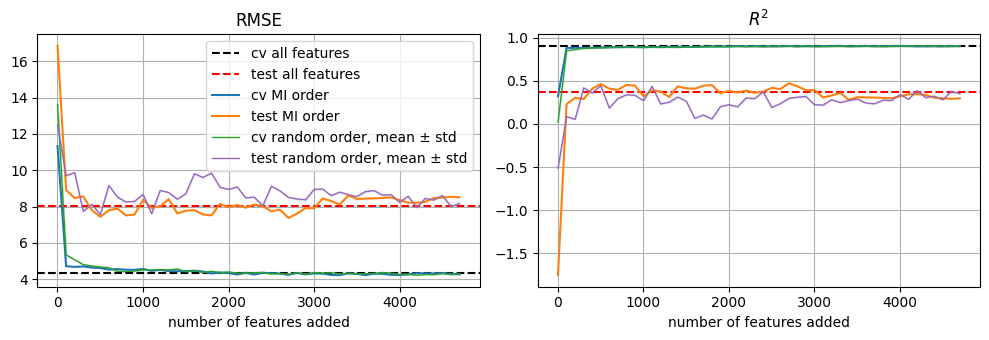

In [156]:
plt.figure(figsize=(10,3.5))

plt.subplot(1,2,1) 
plt.axhline(y=rmse_cv, color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=rmse_test, color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_plot, rmse_cv_arr_mi_add, color='tab:blue', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_plot, rmse_test_arr_mi_add, color='tab:orange', label = "test MI order", linewidth=1.5)
plt.plot(num_feat_plot, rmse_cv_curve["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, rmse_cv_curve["mean"] - rmse_cv_curve["std"], rmse_cv_curve["mean"] + rmse_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, rmse_test_curve["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, rmse_test_curve["mean"] - rmse_test_curve["std"], rmse_test_curve["mean"] + rmse_test_curve["std"], alpha=0.2, color='tab:purple')


#plt.xscale("log")
plt.xlabel("number of features added")
plt.title("RMSE")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2) 
plt.axhline(y=r2_cv, color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=r2_test, color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_plot, r2_test_arr_mi_add, color='tab:orange', label = "test MI order", linewidth=1.5)
plt.plot(num_feat_plot, r2_cv_arr_mi_add, color='tab:blue', label = "cv MI order", linewidth=1.5)

plt.plot(num_feat_plot, r2_cv_curve["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, r2_cv_curve["mean"] - r2_cv_curve["std"], r2_cv_curve["mean"] + r2_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, r2_test_curve["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, r2_test_curve["mean"] - r2_test_curve["std"], r2_test_curve["mean"] + r2_test_curve["std"], alpha=0.2, color='tab:purple')
#plt.xscale("log")
plt.xlabel("number of features added")
plt.title(r"$R^2$")
plt.grid(True)
#plt.legend()
plt.tight_layout() 
plt.savefig(f"{OUTPUT_DIRECTORY}/rmse_r2_feat_added.pdf", format="pdf")  

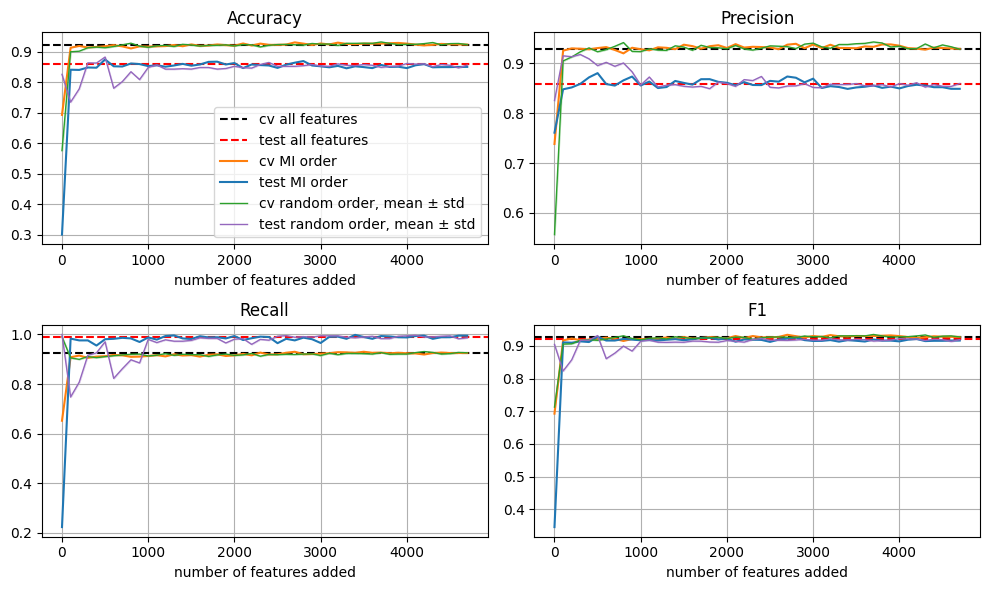

In [157]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["accuracy"], color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=dict_res_two_class["test_metrics"]["accuracy"], color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_plot, gating_cv_metrics['accuracy_arr'], color='tab:orange', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_plot, gating_test_metrics['accuracy_arr'], color='tab:blue', label = "test MI order", linewidth=1.5)

#rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve 
plt.plot(num_feat_plot, gating_accur_cv_curve["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, gating_accur_cv_curve["mean"] - gating_accur_cv_curve["std"], gating_accur_cv_curve["mean"] + gating_accur_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, gating_accur_test_curve["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, gating_accur_test_curve["mean"] - gating_accur_test_curve["std"], gating_accur_test_curve["mean"] + gating_accur_test_curve["std"], alpha=0.2, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features added")
plt.title("Accuracy")
plt.grid(True)
plt.legend()


plt.subplot(2,2,2) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["precision"], color='black', linestyle='--', linewidth=1.5, label='cv baseline (all features)')
plt.axhline(y=dict_res_two_class["test_metrics"]["precision"], color='red', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.plot(num_feat_plot, gating_cv_metrics['precision_arr'], color='tab:orange', label = "gating accuracy cv", linewidth=1.5)
plt.plot(num_feat_plot, gating_test_metrics['precision_arr'], color='tab:blue', label = "gating accuracy test", linewidth=1.5)

#rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve 
plt.plot(num_feat_plot, gating_preci_cv_curve["mean"], label="cv random, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, gating_preci_cv_curve["mean"] - gating_preci_cv_curve["std"], gating_preci_cv_curve["mean"] + gating_preci_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, gating_preci_test_curve["mean"], label="test random, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, gating_preci_test_curve["mean"] - gating_preci_test_curve["std"], gating_preci_test_curve["mean"] + gating_preci_test_curve["std"], alpha=0.2, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features added")
plt.title("Precision")
plt.grid(True)

plt.subplot(2,2,3) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["recall"], color='black', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.axhline(y=dict_res_two_class["test_metrics"]["recall"], color='red', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.plot(num_feat_plot, gating_cv_metrics['recall_arr'], color='tab:orange', label = "gating accuracy cv", linewidth=1.5)
plt.plot(num_feat_plot, gating_test_metrics['recall_arr'], color='tab:blue', label = "gating accuracy test", linewidth=1.5)

#rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve 
plt.plot(num_feat_plot, gating_recall_cv_curve["mean"], label="cv random, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, gating_recall_cv_curve["mean"] - gating_recall_cv_curve["std"], gating_recall_cv_curve["mean"] + gating_recall_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, gating_recall_test_curve["mean"], label="test random, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, gating_recall_test_curve["mean"] - gating_recall_test_curve["std"], gating_recall_test_curve["mean"] + gating_recall_test_curve["std"], alpha=0.2, color='tab:purple')
#plt.xscale("log")

#plt.xscale("log")
plt.xlabel("number of features added")
plt.title("Recall")
plt.grid(True)

plt.subplot(2,2,4)
plt.axhline(y=dict_res_two_class["cv_metrics"]["f1"], color='black', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.axhline(y=dict_res_two_class["test_metrics"]["f1"], color='red', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.plot(num_feat_plot, gating_cv_metrics['f1_arr'], color='tab:orange', label = "gating accuracy cv", linewidth=1.5)
plt.plot(num_feat_plot, gating_test_metrics['f1_arr'], color='tab:blue', label = "gating accuracy test", linewidth=1.5)

#rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve 
plt.plot(num_feat_plot, gating_f1_cv_curve["mean"], label="cv random, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_plot, gating_f1_cv_curve["mean"] - gating_f1_cv_curve["std"], gating_f1_cv_curve["mean"] + gating_f1_cv_curve["std"], alpha=0.2, color='tab:green')
plt.plot(num_feat_plot, gating_f1_test_curve["mean"], label="test random, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_plot, gating_f1_test_curve["mean"] - gating_f1_test_curve["std"], gating_f1_test_curve["mean"] + gating_f1_test_curve["std"], alpha=0.2, color='tab:purple')

#plt.ylim([0.5, 1])
plt.xlabel("number of features added")
plt.title("F1")
plt.grid(True)

#plt.xscale("log")
#plt.yscale("log")

plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/gating_accur_feat_added.pdf", format="pdf")  

In [158]:
dict_res_two_class["cv_metrics"]

{'accuracy': 0.9223826714801444,
 'precision': 0.9283276450511946,
 'recall': 0.9251700680272109,
 'f1': 0.9267461669505963}

In [159]:
dict_res_two_class["test_metrics"]

{'accuracy': 0.8590250329380764,
 'precision': 0.859515570934256,
 'recall': 0.99122106943336,
 'f1': 0.9206819866567828}

In [160]:
feat_removal = True
rmse_test_arr_mi_rem, r2_test_arr_mi_rem, rmse_cv_arr_mi_rem, r2_cv_arr_mi_rem, num_feat_plot_rem, gating_cv_metrics_rem, gating_test_metrics_rem = xgboost_accuracy_multi_expert(X_train.cpu(), X_test.cpu(), y_train, y_test, sorted_cog_idx_by_mi, feat_step, feat_removal)


unning mixture of experts...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [06:48<00:00,  8.51s/it]

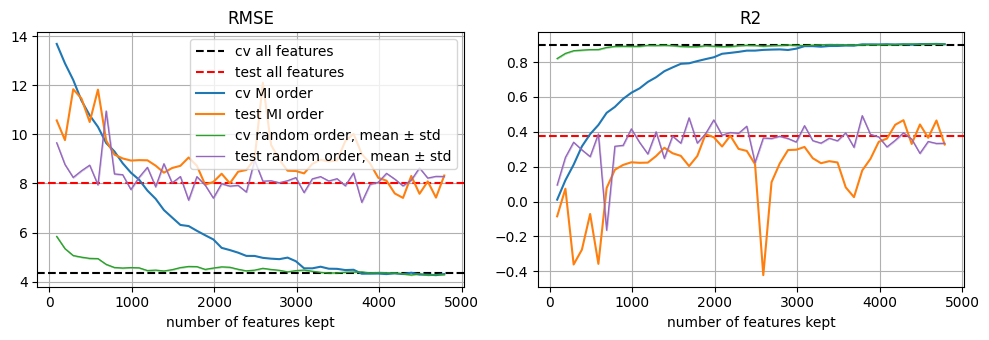

In [161]:
plt.figure(figsize=(10,3.5))

tot_num_feat = X_train.cpu().shape[1]
num_feat_kept = [tot_num_feat - n  for n in num_feat_plot_rem]

plt.subplot(1,2,1) 
plt.axhline(y=rmse_cv, color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=rmse_test, color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_kept, rmse_cv_arr_mi_rem, color='tab:blue', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_kept, rmse_test_arr_mi_rem, color='tab:orange', label = "test MI order", linewidth=1.5)

#rmse_test_curve, r2_test_curve, rmse_cv_curve, r2_cv_curve, gating_accur_cv_curve, gating_preci_cv_curve, gating_recall_cv_curve, gating_f1_cv_curve, gating_accur_test_curve, gating_preci_test_curve, gating_recall_test_curve, gating_f1_test_curve 
plt.plot(num_feat_kept, rmse_cv_curve_rem["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, rmse_cv_curve_rem["mean"] - rmse_cv_curve_rem["std"], rmse_cv_curve_rem["mean"] + rmse_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, rmse_test_curve_rem["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, rmse_test_curve_rem["mean"] - rmse_test_curve_rem["std"], rmse_test_curve_rem["mean"] + rmse_test_curve_rem["std"], alpha=0.3, color='tab:purple')
#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("RMSE")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2) 
plt.axhline(y=r2_cv, color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=r2_test, color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_kept, r2_cv_arr_mi_rem, color='tab:blue', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_kept, r2_test_arr_mi_rem, color='tab:orange', label = "test MI order", linewidth=1.5)

plt.plot(num_feat_kept, r2_cv_curve_rem["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, r2_cv_curve_rem["mean"] - r2_cv_curve_rem["std"], r2_cv_curve_rem["mean"] + r2_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, r2_test_curve_rem["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, r2_test_curve_rem["mean"] - r2_test_curve_rem["std"], r2_test_curve_rem["mean"] + r2_test_curve_rem["std"], alpha=0.3, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("R2")
plt.grid(True)
#plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/rmse_r2_feat_removed.pdf", format="pdf")  

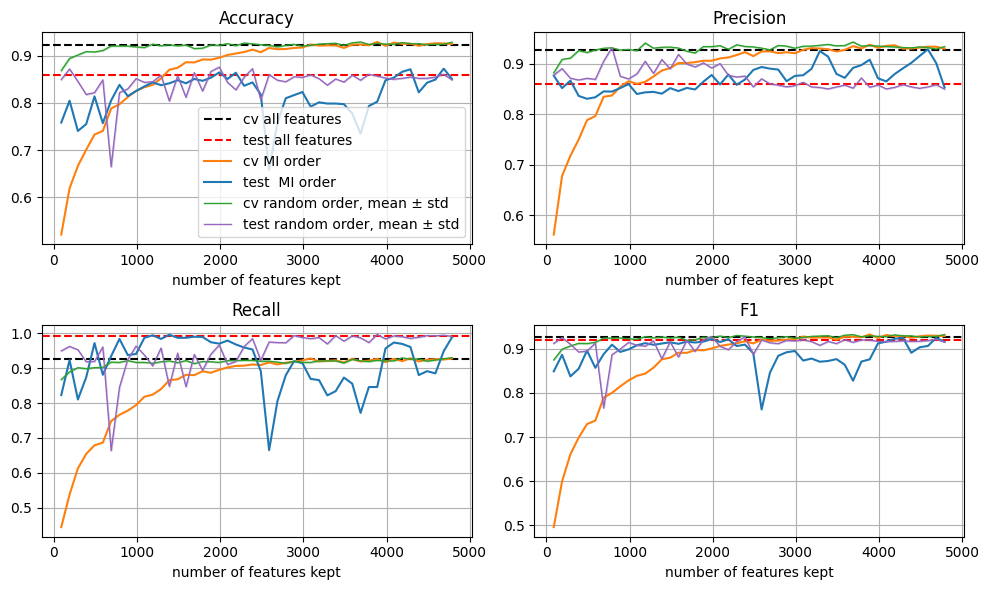

In [162]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["accuracy"], color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=dict_res_two_class["test_metrics"]["accuracy"], color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_kept, gating_cv_metrics_rem['accuracy_arr'], color='tab:orange', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_kept, gating_test_metrics_rem['accuracy_arr'], color='tab:blue', label = "test  MI order", linewidth=1.5)

plt.plot(num_feat_kept, gating_accur_cv_curve_rem["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, gating_accur_cv_curve_rem["mean"] - gating_accur_cv_curve_rem["std"], gating_accur_cv_curve_rem["mean"] + gating_accur_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, gating_accur_test_curve_rem["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, gating_accur_test_curve_rem["mean"] - gating_accur_test_curve_rem["std"], gating_accur_test_curve_rem["mean"] + gating_accur_test_curve_rem["std"], alpha=0.3, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("Accuracy")
plt.grid(True)
plt.legend()


plt.subplot(2,2,2) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["precision"], color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=dict_res_two_class["test_metrics"]["precision"], color='red', linestyle='--', linewidth=1.5, label='test all features')
plt.plot(num_feat_kept, gating_cv_metrics_rem['precision_arr'], color='tab:orange', label = "cv MI order", linewidth=1.5)
plt.plot(num_feat_kept, gating_test_metrics_rem['precision_arr'], color='tab:blue', label = "test  MI order", linewidth=1.5)

plt.plot(num_feat_kept, gating_preci_cv_curve_rem["mean"], label="cv random order, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, gating_preci_cv_curve_rem["mean"] - gating_preci_cv_curve_rem["std"], gating_preci_cv_curve_rem["mean"] + gating_preci_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, gating_preci_test_curve_rem["mean"], label="test random order, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, gating_preci_test_curve_rem["mean"] - gating_preci_test_curve_rem["std"], gating_preci_test_curve_rem["mean"] + gating_preci_test_curve_rem["std"], alpha=0.3, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("Precision")
plt.grid(True)

plt.subplot(2,2,3) 
plt.axhline(y=dict_res_two_class["cv_metrics"]["recall"], color='black', linestyle='--', linewidth=1.5, label='cv all features')
plt.axhline(y=dict_res_two_class["test_metrics"]["recall"], color='red', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.plot(num_feat_kept, gating_cv_metrics_rem['recall_arr'], color='tab:orange', label = "gating accuracy cv", linewidth=1.5)
plt.plot(num_feat_kept, gating_test_metrics_rem['recall_arr'], color='tab:blue', label = "gating accuracy test", linewidth=1.5)

plt.plot(num_feat_kept, gating_recall_cv_curve_rem["mean"], label="cv random, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, gating_recall_cv_curve_rem["mean"] - gating_recall_cv_curve_rem["std"], gating_recall_cv_curve_rem["mean"] + gating_recall_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, gating_recall_test_curve_rem["mean"], label="test random, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, gating_recall_test_curve_rem["mean"] - gating_recall_test_curve_rem["std"], gating_recall_test_curve_rem["mean"] + gating_recall_test_curve_rem["std"], alpha=0.3, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("Recall")
plt.grid(True)

plt.subplot(2,2,4)
plt.axhline(y=dict_res_two_class["cv_metrics"]["f1"], color='black', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.axhline(y=dict_res_two_class["test_metrics"]["f1"], color='red', linestyle='--', linewidth=1.5, label='test baseline (all features)')
plt.plot(num_feat_kept, gating_cv_metrics_rem['f1_arr'], color='tab:orange', label = "gating accuracy cv", linewidth=1.5)
plt.plot(num_feat_kept, gating_test_metrics_rem['f1_arr'], color='tab:blue', label = "gating accuracy test", linewidth=1.5)

plt.plot(num_feat_kept, gating_f1_cv_curve_rem["mean"], label="cv random, mean ± std", color='tab:green', linewidth=1)
plt.fill_between(num_feat_kept, gating_f1_cv_curve_rem["mean"] - gating_f1_cv_curve_rem["std"], gating_f1_cv_curve_rem["mean"] + gating_f1_cv_curve_rem["std"], alpha=0.3, color='tab:green')
plt.plot(num_feat_kept, gating_f1_test_curve_rem["mean"], label="test random, mean ± std", color='tab:purple', linewidth=1)
plt.fill_between(num_feat_kept, gating_f1_test_curve_rem["mean"] - gating_f1_test_curve_rem["std"], gating_f1_test_curve_rem["mean"] + gating_f1_test_curve_rem["std"], alpha=0.3, color='tab:purple')

#plt.xscale("log")
plt.xlabel("number of features kept")
plt.title("F1")

plt.grid(True)
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/gating_accur_feat_removed.pdf", format="pdf")  